# Assignment 2 - Applied Data Science 

## 0. Import packages and set up project folders

In [1]:
import os
import gc
import pickle
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Move to main project folder
os.chdir("/home/jovyan/lauren")

print("Current folder:")
print(os.getcwd())

# Create output folders
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

print("\nFolders here:")
print(os.listdir("."))

print("\nData files:")
print(os.listdir("data"))

print("\nOutput folders:")
print(os.listdir("outputs"))

Current folder:
/home/jovyan/lauren

Folders here:
['Current.ipynb', 'outputs', 'data', 'notebook', 'final_stec.ipynb', 'scripts', '.ipynb_checkpoints']

Data files:
['19kmerdata.txt', '14-18metadata', '14-18kmerdata.txt', '19metadata', '.ipynb_checkpoints']

Output folders:
['tables', 'models', 'figures', '.ipynb_checkpoints']


## 1. Load k-mer matrices and metadata files

In [2]:
# Load k-mer files
# These are tab-separated
train_kmers = pd.read_csv("data/14-18kmerdata.txt", sep="\t", index_col=0)
test_kmers = pd.read_csv("data/19kmerdata.txt", sep="\t", index_col=0)

# Load metadata files
# These are comma-separated
train_meta = pd.read_csv("data/14-18metadata", sep=",")
test_meta = pd.read_csv("data/19metadata", sep=",")

# Set accession/sample ID as metadata index
train_meta = train_meta.set_index("Accession")
test_meta = test_meta.set_index("Accession")

# Clean metadata index
train_meta.index = train_meta.index.astype(str).str.strip()
test_meta.index = test_meta.index.astype(str).str.strip()

print("Files loaded successfully.")

print("\nOriginal k-mer shapes:")
print("Training k-mers:", train_kmers.shape)
print("Testing k-mers:", test_kmers.shape)

print("\nMetadata shapes:")
print("Training metadata:", train_meta.shape)
print("Testing metadata:", test_meta.shape)

print("\nMetadata columns:")
print(train_meta.columns.tolist())

display(train_meta.head())
display(test_meta.head())

Files loaded successfully.

Original k-mer shapes:
Training k-mers: (49999, 2459)
Testing k-mers: (49999, 415)

Metadata shapes:
Training metadata: (2459, 5)
Testing metadata: (415, 5)

Metadata columns:
['Country', 'Region', 'Year', 'Stx', 'PT']


,Country,Region,Year,Stx,PT
Accession,,,,,
SRR7282660,N,UK,2018,stx1a,PT8
SRR7416051,N,UK,2018,stx1a,PT8
SRR7516055,N,UK,2018,stx1a,PT4
SRR7826924,N,UK,2018,stx1a,PT8
SRR7842173,N,UK,2018,stx1a,PT4


,Country,Region,Year,Stx,PT
Accession,,,,,
SRR10002237,Turkey,M. East,2019,stx2c stx1a,PT 8
SRR10010915,Spain,S. Europe,2019,stx2c stx1a,PT 31
SRR10010916,N,UK,2019,stx2a,PT 8
SRR10010917,N,UK,2019,stx2a stx2c,PT 21/28
SRR10010918,N,UK,2019,stx2a stx2c stx1a,PT 8


## 2. Clean and standardise country labels

In [3]:
# Clean country label spelling/formatting

country_corrections = {
    "N": "UK",
    "Wales": "UK",
    "Portgual": "Portugal",
    "Philipines": "Philippines",
    "Saudia Arabia": "Saudi Arabia",
    "Holland": "Netherlands"
}

train_meta["Country"] = train_meta["Country"].replace(country_corrections)
test_meta["Country"] = test_meta["Country"].replace(country_corrections)

# Remove leading/trailing spaces
train_meta["Country"] = train_meta["Country"].astype(str).str.strip()
test_meta["Country"] = test_meta["Country"].astype(str).str.strip()

print("Cleaned training countries:")
print(sorted(train_meta["Country"].unique()))

print("\nCleaned testing countries:")
print(sorted(test_meta["Country"].unique()))

print("\nTraining country counts after cleaning:")
print(train_meta["Country"].value_counts())

print("\nTesting country counts after cleaning:")
print(test_meta["Country"].value_counts())

Cleaned training countries:
['Albania', 'Algeria', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bangladesh', 'Barbados', 'Belgium', 'Bhutan', 'Bulgaria', 'Canada', 'Cape Verde', 'China', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Egypt', 'Faroe Islands', 'France', 'Germany', 'Ghana', 'Greece', 'Guernsey', 'Hungary', 'India', 'Indonesia', 'Iran', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Madagascar', 'Maldives', 'Malta', 'Mexico', 'Morocco', 'Nepal', 'New Zealand', 'Nigeria', 'Pakistan', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Qatar', 'Romania', 'Saudi Arabia', 'Serbia', 'South Africa', 'Spain', 'Sri Lanka', 'St Vincent and the Grenadines', 'Switzerland', 'Tanzania', 'Thailand', 'Tunisia', 'Turkey', 'UAE', 'UK', 'USA', 'Uganda', 'Vietnam']

Cleaned testing countries:
['Albania', 'Antigua', 'Australia', 'Azerbaijan', 'Bangladesh', 'Belgium', 'Bulgaria', 'China', 'Croatia', 'Cyprus', 'Denmark', '

## 3. Transpose k-mer matrices so isolates are rows and k-mers are columns

In [4]:
print("Before transpose:")
print("Training k-mer index first 5:", train_kmers.index[:5].tolist())
print("Training k-mer columns first 5:", train_kmers.columns[:5].tolist())
print("Testing k-mer index first 5:", test_kmers.index[:5].tolist())
print("Testing k-mer columns first 5:", test_kmers.columns[:5].tolist())

# Transpose so samples become rows and k-mers become columns
train_kmers = train_kmers.T
test_kmers = test_kmers.T

# Clean sample names after transpose
train_kmers.index = train_kmers.index.astype(str).str.strip()
test_kmers.index = test_kmers.index.astype(str).str.strip()

print("\nAfter transpose:")
print("Training k-mers:", train_kmers.shape)
print("Testing k-mers:", test_kmers.shape)
print("Training sample IDs first 5:", train_kmers.index[:5].tolist())
print("Testing sample IDs first 5:", test_kmers.index[:5].tolist())

Before transpose:
Training k-mer index first 5: ['TTTTTTTTTT', 'TTTTTTTTTTT', 'TTTTTTTTTTTT', 'TTTTTTTTTTTTT', 'TTTTTTTTTTTTTT']
Training k-mer columns first 5: ['SRR3530392', 'SRR3530530', 'SRR3530616', 'SRR3531422', 'SRR3531744']
Testing k-mer index first 5: ['TTTTTTTTTT', 'TTTTTTTTTTT', 'TTTTTTTTTTTT', 'TTTTTTTTTTTTT', 'TTTTTTTTTTTTTT']
Testing k-mer columns first 5: ['SRR10002237', 'SRR10010915', 'SRR10010916', 'SRR10010917', 'SRR10010918']

After transpose:
Training k-mers: (2459, 49999)
Testing k-mers: (415, 49999)
Training sample IDs first 5: ['SRR3530392', 'SRR3530530', 'SRR3530616', 'SRR3531422', 'SRR3531744']
Testing sample IDs first 5: ['SRR10002237', 'SRR10010915', 'SRR10010916', 'SRR10010917', 'SRR10010918']


## 4. Match k-mer profiles to metadata using accession IDs

In [5]:
train_common = train_kmers.index.intersection(train_meta.index)
test_common = test_kmers.index.intersection(test_meta.index)

print("Matching samples before alignment:")
print("Training samples matching:", len(train_common))
print("Testing samples matching:", len(test_common))

print("\nOriginal row counts:")
print("Training k-mer rows:", train_kmers.shape[0])
print("Training metadata rows:", train_meta.shape[0])
print("Testing k-mer rows:", test_kmers.shape[0])
print("Testing metadata rows:", test_meta.shape[0])

if len(train_common) == 0:
    print("\nExample training k-mer IDs:")
    print(train_kmers.index[:10].tolist())
    print("\nExample training metadata IDs:")
    print(train_meta.index[:10].tolist())
    raise ValueError("No training samples match.")

if len(test_common) == 0:
    print("\nExample testing k-mer IDs:")
    print(test_kmers.index[:10].tolist())
    print("\nExample testing metadata IDs:")
    print(test_meta.index[:10].tolist())
    raise ValueError("No testing samples match.")

# Align to matching samples only
train_kmers = train_kmers.loc[train_common]
train_meta = train_meta.loc[train_common]

test_kmers = test_kmers.loc[test_common]
test_meta = test_meta.loc[test_common]

print("\nAfter sample alignment:")
print("Training k-mers:", train_kmers.shape)
print("Training metadata:", train_meta.shape)
print("Testing k-mers:", test_kmers.shape)
print("Testing metadata:", test_meta.shape)

Matching samples before alignment:
Training samples matching: 2459
Testing samples matching: 415

Original row counts:
Training k-mer rows: 2459
Training metadata rows: 2459
Testing k-mer rows: 415
Testing metadata rows: 415

After sample alignment:
Training k-mers: (2459, 49999)
Training metadata: (2459, 5)
Testing k-mers: (415, 49999)
Testing metadata: (415, 5)


## 5. Define country and region target labels

In [6]:
country_col = "Country"
region_col = "Region"

print("Metadata columns:")
print(train_meta.columns.tolist())

print("\nMissing labels:")
print("Missing training country labels:", train_meta[country_col].isna().sum())
print("Missing testing country labels:", test_meta[country_col].isna().sum())
print("Missing training region labels:", train_meta[region_col].isna().sum())
print("Missing testing region labels:", test_meta[region_col].isna().sum())

print("\nTraining country counts:")
print(train_meta[country_col].value_counts())

print("\nTraining region counts:")
print(train_meta[region_col].value_counts())

Metadata columns:
['Country', 'Region', 'Year', 'Stx', 'PT']

Missing labels:
Missing training country labels: 0
Missing testing country labels: 0
Missing training region labels: 0
Missing testing region labels: 0

Training country counts:
Country
UK               1907
Spain             101
Turkey             84
Morocco            34
Egypt              23
                 ... 
Faroe Islands       1
Germany             1
Australia           1
Bhutan              1
Uganda              1
Name: count, Length: 70, dtype: int64

Training region counts:
Region
UK                   1907
S. Europe             193
M. East               112
N. Africa              72
C. Europe              49
Asia                   47
Subsaharan Africa      25
C. America             24
N. Europe              12
N. America             11
Australasia             4
S. America              3
Name: count, dtype: int64


## 6. Create country-level and region-level modelling datasets

In [7]:
# Country dataset
country_train_keep = train_meta[country_col].notna()
country_test_keep = test_meta[country_col].notna()

X_train_country = train_kmers.loc[country_train_keep]
X_test_country = test_kmers.loc[country_test_keep]

y_train_country = train_meta.loc[country_train_keep, country_col].astype(str)
y_test_country = test_meta.loc[country_test_keep, country_col].astype(str)

# Region dataset
region_train_keep = train_meta[region_col].notna()
region_test_keep = test_meta[region_col].notna()

X_train_region = train_kmers.loc[region_train_keep]
X_test_region = test_kmers.loc[region_test_keep]

y_train_region = train_meta.loc[region_train_keep, region_col].astype(str)
y_test_region = test_meta.loc[region_test_keep, region_col].astype(str)

# Align features between train and test
X_train_country, X_test_country = X_train_country.align(
    X_test_country,
    join="inner",
    axis=1
)

X_train_region, X_test_region = X_train_region.align(
    X_test_region,
    join="inner",
    axis=1
)

print("Original country dataset:")
print("X_train_country:", X_train_country.shape)
print("X_test_country:", X_test_country.shape)
print("y_train_country:", y_train_country.shape)
print("y_test_country:", y_test_country.shape)

print("\nOriginal region dataset:")
print("X_train_region:", X_train_region.shape)
print("X_test_region:", X_test_region.shape)
print("y_train_region:", y_train_region.shape)
print("y_test_region:", y_test_region.shape)

print("\nCheck orientation:")
print("Country index first 5:", X_train_country.index[:5].tolist())
print("Country k-mer columns first 5:", X_train_country.columns[:5].tolist())

Original country dataset:
X_train_country: (2459, 49999)
X_test_country: (415, 49999)
y_train_country: (2459,)
y_test_country: (415,)

Original region dataset:
X_train_region: (2459, 49999)
X_test_region: (415, 49999)
y_train_region: (2459,)
y_test_region: (415,)

Check orientation:
Country index first 5: ['SRR3530392', 'SRR3530530', 'SRR3530616', 'SRR3531422', 'SRR3531744']
Country k-mer columns first 5: ['TTTTTTTTTT', 'TTTTTTTTTTT', 'TTTTTTTTTTTT', 'TTTTTTTTTTTTT', 'TTTTTTTTTTTTTT']


## 7. Summarise dataset size, feature number and class number

In [8]:
dataset_summary = pd.DataFrame({
    "Dataset": ["Country training", "Country testing", "Region training", "Region testing"],
    "Samples": [
        X_train_country.shape[0],
        X_test_country.shape[0],
        X_train_region.shape[0],
        X_test_region.shape[0]
    ],
    "Kmer_features": [
        X_train_country.shape[1],
        X_test_country.shape[1],
        X_train_region.shape[1],
        X_test_region.shape[1]
    ],
    "Classes": [
        y_train_country.nunique(),
        y_test_country.nunique(),
        y_train_region.nunique(),
        y_test_region.nunique()
    ]
})

display(dataset_summary)

dataset_summary.to_csv(
    "outputs/tables/dataset_summary.csv",
    index=False
)

,Dataset,Samples,Kmer_features,Classes
0,Country training,2459,49999,70
1,Country testing,415,49999,41
2,Region training,2459,49999,12
3,Region testing,415,49999,11


## 8. Visualise country and region class distributions

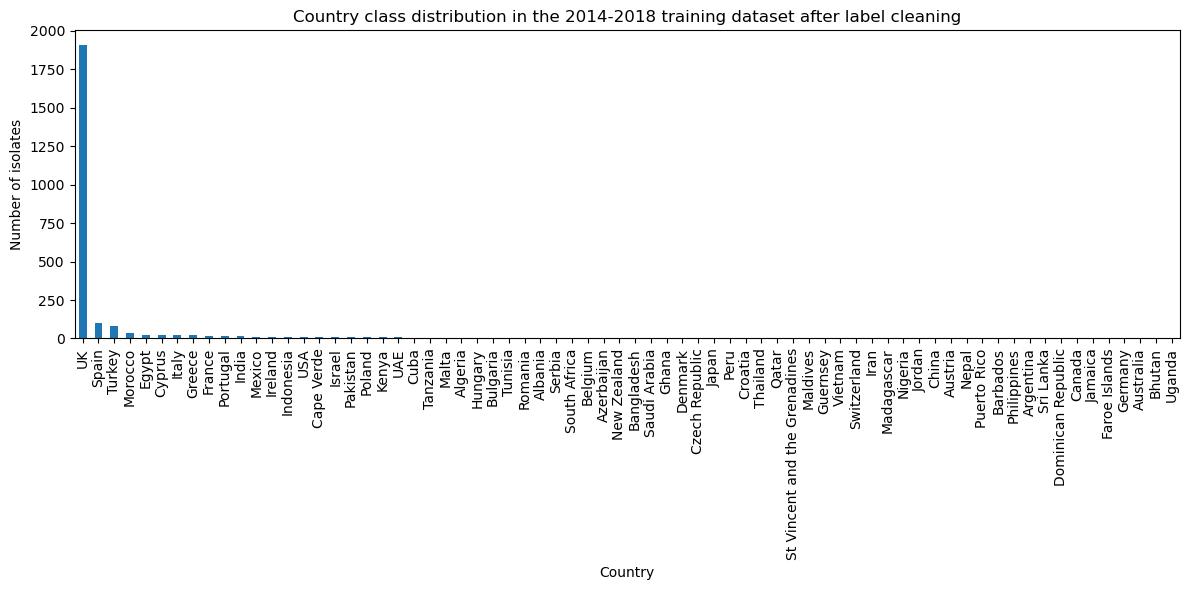

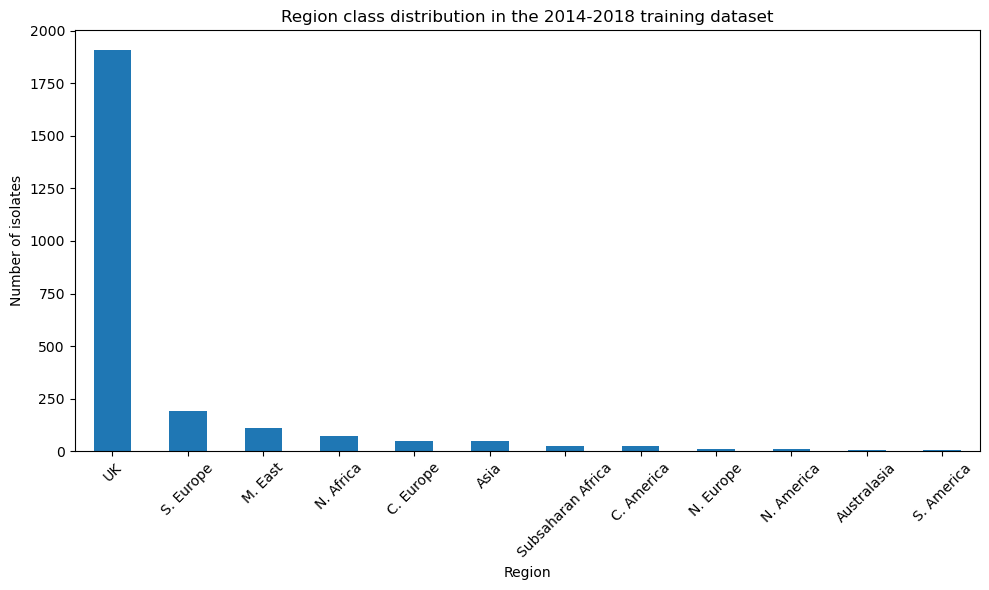

In [9]:
# Country class distribution after cleaning

plt.figure(figsize=(12, 6))
y_train_country.value_counts().plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Number of isolates")
plt.title("Country class distribution in the 2014-2018 training dataset after label cleaning")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("outputs/figures/figure1_country_class_distribution_cleaned.png", dpi=300)
plt.show()


# Region class distribution

plt.figure(figsize=(10, 6))
y_train_region.value_counts().plot(kind="bar")
plt.xlabel("Region")
plt.ylabel("Number of isolates")
plt.title("Region class distribution in the 2014-2018 training dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/figures/figure2_region_class_distribution.png", dpi=300)
plt.show()

## 9. Train and evaluate the baseline country Random Forest model

In [10]:
seed = 1

country_model = RandomForestClassifier(
    n_estimators=1000,
    random_state=seed,
    n_jobs=-1,
    class_weight="balanced"
)

country_model.fit(X_train_country, y_train_country)

country_pred = country_model.predict(X_test_country)

country_accuracy = accuracy_score(y_test_country, country_pred)
country_balanced_accuracy = balanced_accuracy_score(y_test_country, country_pred)
country_macro_precision = precision_score(y_test_country, country_pred, average="macro", zero_division=0)
country_macro_recall = recall_score(y_test_country, country_pred, average="macro", zero_division=0)
country_macro_f1 = f1_score(y_test_country, country_pred, average="macro", zero_division=0)
country_weighted_f1 = f1_score(y_test_country, country_pred, average="weighted", zero_division=0)
country_mcc = matthews_corrcoef(y_test_country, country_pred)

country_report = classification_report(
    y_test_country,
    country_pred,
    output_dict=True,
    zero_division=0
)

country_report_df = pd.DataFrame(country_report).transpose()

print("ORIGINAL COUNTRY MODEL")
print("Accuracy:", country_accuracy)
print("Balanced accuracy:", country_balanced_accuracy)
print("Macro precision:", country_macro_precision)
print("Macro recall:", country_macro_recall)
print("Macro F1:", country_macro_f1)
print("Weighted F1:", country_weighted_f1)
print("MCC:", country_mcc)
print(classification_report(y_test_country, country_pred, zero_division=0))

country_report_df.to_csv(
    "outputs/tables/original_country_classification_report.csv"
)

ORIGINAL COUNTRY MODEL
Accuracy: 0.6963855421686747
Balanced accuracy: 0.0665852079938131
Macro precision: 0.09988261379940001
Macro recall: 0.0665852079938131
Macro F1: 0.07389886900276052
Weighted F1: 0.6048478485289899
MCC: 0.3388274489543654
              precision    recall  f1-score   support

     Albania       0.00      0.00      0.00         1
     Antigua       0.00      0.00      0.00         3
   Australia       0.00      0.00      0.00         2
  Azerbaijan       0.00      0.00      0.00         1
  Bangladesh       0.00      0.00      0.00         1
     Belgium       0.00      0.00      0.00         2
    Bulgaria       0.00      0.00      0.00         2
       China       0.00      0.00      0.00         2
     Croatia       0.00      0.00      0.00         2
      Cyprus       0.67      0.22      0.33         9
     Denmark       0.00      0.00      0.00         2
       Egypt       1.00      0.27      0.43        11
      France       0.00      0.00      0.00        

## 10. Generate confusion matrix for the baseline country model

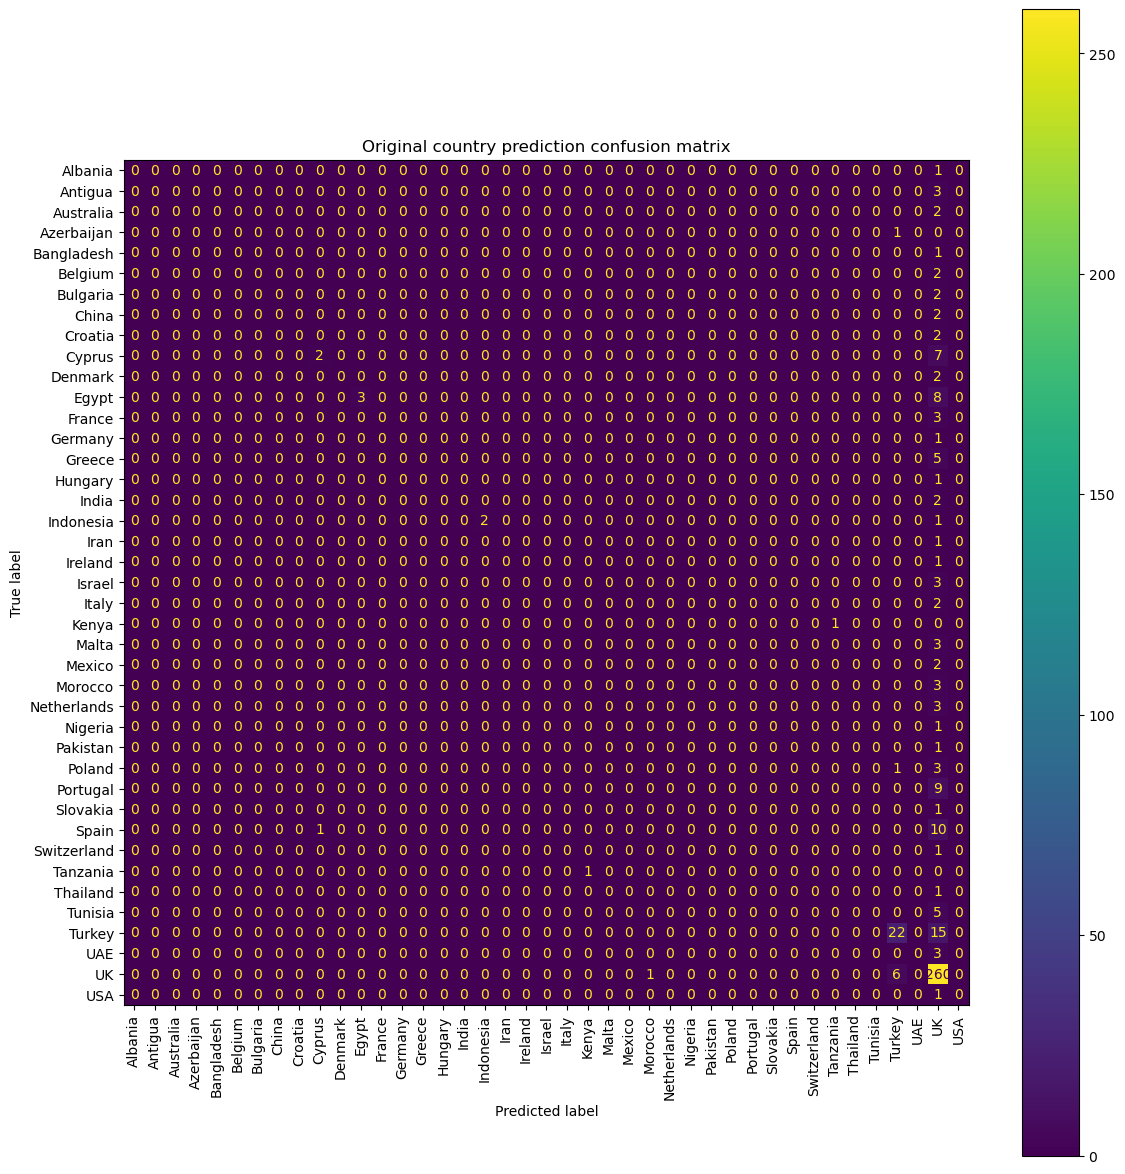

In [11]:
country_labels = sorted(y_test_country.unique())

cm_country = confusion_matrix(
    y_test_country,
    country_pred,
    labels=country_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_country,
    display_labels=country_labels
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Original country prediction confusion matrix")
plt.tight_layout()
plt.savefig("outputs/figures/figure3_original_country_confusion_matrix.png", dpi=300)
plt.show()

## 11. Train and evaluate the baseline region Random Forest model

In [12]:
region_model = RandomForestClassifier(
    n_estimators=1000,
    random_state=seed,
    n_jobs=-1,
    class_weight="balanced"
)

region_model.fit(X_train_region, y_train_region)

region_pred = region_model.predict(X_test_region)

region_accuracy = accuracy_score(y_test_region, region_pred)
region_balanced_accuracy = balanced_accuracy_score(y_test_region, region_pred)
region_macro_precision = precision_score(y_test_region, region_pred, average="macro", zero_division=0)
region_macro_recall = recall_score(y_test_region, region_pred, average="macro", zero_division=0)
region_macro_f1 = f1_score(y_test_region, region_pred, average="macro", zero_division=0)
region_weighted_f1 = f1_score(y_test_region, region_pred, average="weighted", zero_division=0)
region_mcc = matthews_corrcoef(y_test_region, region_pred)

region_report = classification_report(
    y_test_region,
    region_pred,
    output_dict=True,
    zero_division=0
)

region_report_df = pd.DataFrame(region_report).transpose()

print("ORIGINAL REGION MODEL")
print("Accuracy:", region_accuracy)
print("Balanced accuracy:", region_balanced_accuracy)
print("Macro precision:", region_macro_precision)
print("Macro recall:", region_macro_recall)
print("Macro F1:", region_macro_f1)
print("Weighted F1:", region_weighted_f1)
print("MCC:", region_mcc)
print(classification_report(y_test_region, region_pred, zero_division=0))

region_report_df.to_csv(
    "outputs/tables/original_region_classification_report.csv"
)

ORIGINAL REGION MODEL
Accuracy: 0.7132530120481928
Balanced accuracy: 0.2664743505155311
Macro precision: 0.4346145115808037
Macro recall: 0.2664743505155311
Macro F1: 0.30369415405455263
Weighted F1: 0.6512593771311661
MCC: 0.39244733629816564
                   precision    recall  f1-score   support

             Asia       1.00      0.40      0.57        10
      Australasia       0.00      0.00      0.00         2
       C. America       0.00      0.00      0.00         5
        C. Europe       0.00      0.00      0.00        13
          M. East       0.69      0.60      0.64        45
        N. Africa       0.60      0.16      0.25        19
       N. America       0.00      0.00      0.00         1
        N. Europe       0.00      0.00      0.00         6
        S. Europe       0.78      0.16      0.26        44
Subsaharan Africa       1.00      0.67      0.80         3
               UK       0.71      0.95      0.81       267

         accuracy                           0

## 12. Generate confusion matrix for the baseline region model

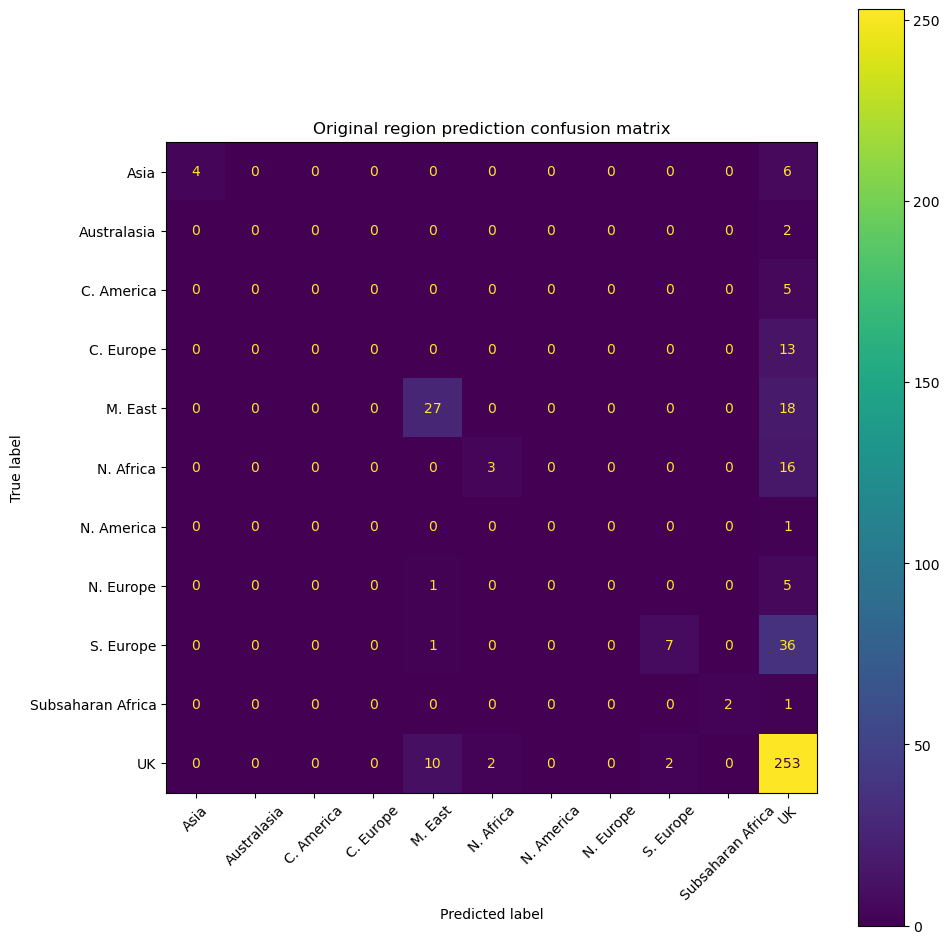

In [13]:
region_labels = sorted(y_test_region.unique())

cm_region = confusion_matrix(
    y_test_region,
    region_pred,
    labels=region_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_region,
    display_labels=region_labels
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Original region prediction confusion matrix")
plt.tight_layout()
plt.savefig("outputs/figures/figure4_original_region_confusion_matrix.png", dpi=300)
plt.show()

## 13. Compare baseline country and region model performance

In [14]:
original_comparison = pd.DataFrame({
    "Model": ["Original country", "Original region"],
    "Accuracy": [country_accuracy, region_accuracy],
    "Balanced_accuracy": [country_balanced_accuracy, region_balanced_accuracy],
    "Macro_precision": [country_macro_precision, region_macro_precision],
    "Macro_recall": [country_macro_recall, region_macro_recall],
    "Macro_F1": [country_macro_f1, region_macro_f1],
    "Weighted_F1": [country_weighted_f1, region_weighted_f1],
    "MCC": [country_mcc, region_mcc]
})

display(original_comparison)

original_comparison.to_csv(
    "outputs/tables/original_model_comparison.csv",
    index=False
)

,Model,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
0,Original country,0.696386,0.066585,0.099883,0.066585,0.073899,0.604848,0.338827
1,Original region,0.713253,0.266474,0.434615,0.266474,0.303694,0.651259,0.392447


## 14. Define helper functions for filtering, feature selection, balancing and evaluation

In [15]:
def filter_classes(X_train, X_test, y_train, y_test, min_samples=15):
    """
    Keeps only classes:
    - present in both training and testing data
    - represented by at least min_samples in the training set
    """
    shared_classes = set(y_train.unique()).intersection(set(y_test.unique()))
    train_counts = y_train.value_counts()
    enough_samples = set(train_counts[train_counts >= min_samples].index)

    valid_classes = shared_classes.intersection(enough_samples)

    train_keep = y_train.isin(valid_classes)
    test_keep = y_test.isin(valid_classes)

    X_train_filt = X_train.loc[train_keep].copy()
    y_train_filt = y_train.loc[train_keep].copy()

    X_test_filt = X_test.loc[test_keep].copy()
    y_test_filt = y_test.loc[test_keep].copy()

    return X_train_filt, X_test_filt, y_train_filt, y_test_filt


def select_top_variable_kmers(X_train, X_test, top_n):
    """
    Selects the top_n most variable k-mers from the training set.
    If top_n is larger than the number of available features, all features are used.
    """
    max_features_available = X_train.shape[1]

    if top_n >= max_features_available:
        print(f"Requested {top_n} k-mers, but only {max_features_available} available. Using all features.")
        top_features = X_train.columns
    else:
        variances = X_train.var(axis=0)
        top_features = variances.sort_values(ascending=False).head(top_n).index

    X_train_selected = X_train[top_features].copy()
    X_test_selected = X_test[top_features].copy()

    return X_train_selected, X_test_selected, top_features


def balance_training_data(X, y, strategy="none", target_count=80, random_state=34):
    """
    Balancing strategies:
    - none: no resampling
    - undersample_UK: only downsample UK if it is too large
    - undersample_all: downsample all classes above target_count
    - hybrid: oversample small classes and downsample large classes to target_count
    """

    if strategy == "none":
        return X.copy(), y.copy()

    data = X.copy()
    data["__label__"] = y.values

    balanced_parts = []

    if strategy == "undersample_UK":
        for label, group in data.groupby("__label__"):
            if label == "UK" and len(group) > target_count:
                group_balanced = resample(
                    group,
                    replace=False,
                    n_samples=target_count,
                    random_state=random_state
                )
            else:
                group_balanced = group

            balanced_parts.append(group_balanced)

    elif strategy == "undersample_all":
        for label, group in data.groupby("__label__"):
            n_samples = min(len(group), target_count)

            group_balanced = resample(
                group,
                replace=False,
                n_samples=n_samples,
                random_state=random_state
            )

            balanced_parts.append(group_balanced)

    elif strategy == "hybrid":
        for label, group in data.groupby("__label__"):
            if len(group) < target_count:
                group_balanced = resample(
                    group,
                    replace=True,
                    n_samples=target_count,
                    random_state=random_state
                )
            else:
                group_balanced = resample(
                    group,
                    replace=False,
                    n_samples=target_count,
                    random_state=random_state
                )

            balanced_parts.append(group_balanced)

    else:
        raise ValueError("Unknown balancing strategy")

    balanced_data = pd.concat(balanced_parts, axis=0)

    X_balanced = balanced_data.drop(columns="__label__")
    y_balanced = balanced_data["__label__"]

    shuffled_index = np.random.RandomState(random_state).permutation(len(y_balanced))

    X_balanced = X_balanced.iloc[shuffled_index]
    y_balanced = y_balanced.iloc[shuffled_index]

    return X_balanced, y_balanced


def evaluate_model(y_true, y_pred):
    """
    Calculates metrics suitable for imbalanced multiclass classification.
    """
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

## 15. Set up the country model comparison grid

In [16]:
# Filter country data before grid search

X_train_country_grid, X_test_country_grid, y_train_country_grid, y_test_country_grid = filter_classes(
    X_train_country,
    X_test_country,
    y_train_country,
    y_test_country,
    min_samples=15
)

print("Filtered country dataset for grid:")
print("Training data:", X_train_country_grid.shape)
print("Testing data:", X_test_country_grid.shape)
print("Training classes:", y_train_country_grid.nunique())
print("Testing classes:", y_test_country_grid.nunique())

print("\nTraining class counts:")
print(y_train_country_grid.value_counts())

print("\nTesting class counts:")
print(y_test_country_grid.value_counts())


feature_grid = [3000, 5000, 10000, 20000, 30000, 40000, 50000]

balancing_grid = [
    "none",
    "undersample_UK",
    "undersample_all",
    "hybrid"
]

model_grid = [
    {
        "Model_setting": "RF_300_balanced_default",
        "n_estimators": 300,
        "class_weight": "balanced",
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "max_depth": None
    },
    {
        "Model_setting": "RF_500_balanced_subsample_regularised",
        "n_estimators": 500,
        "class_weight": "balanced_subsample",
        "max_features": "sqrt",
        "min_samples_leaf": 2,
        "min_samples_split": 4,
        "max_depth": None
    },
    {
        "Model_setting": "RF_500_restricted_depth",
        "n_estimators": 500,
        "class_weight": "balanced_subsample",
        "max_features": "sqrt",
        "min_samples_leaf": 2,
        "min_samples_split": 6,
        "max_depth": 25
    },
    {
        "Model_setting": "RF_800_balanced_subsample_deeper",
        "n_estimators": 800,
        "class_weight": "balanced_subsample",
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "max_depth": 40
    },
    {
        "Model_setting": "RF_500_log2_features_regularised",
        "n_estimators": 500,
        "class_weight": "balanced_subsample",
        "max_features": "log2",
        "min_samples_leaf": 2,
        "min_samples_split": 4,
        "max_depth": 30
    }
]

target_count = 80

grid_results = []

best_score = -999
best_model = None
best_predictions = None
best_features = None
best_row = None

Filtered country dataset for grid:
Training data: (2246, 49999)
Testing data: (357, 49999)
Training classes: 10
Testing classes: 10

Training class counts:
Country
UK          1907
Spain        101
Turkey        84
Morocco       34
Egypt         23
Cyprus        21
Italy         20
Greece        20
France        19
Portugal      17
Name: count, dtype: int64

Testing class counts:
Country
UK          267
Turkey       37
Spain        11
Egypt        11
Portugal      9
Cyprus        9
Greece        5
France        3
Morocco       3
Italy         2
Name: count, dtype: int64


## 16. Run the country model comparison grid

In [17]:
for top_n in feature_grid:

    print(f"\nSelecting top {top_n} variable k-mers...")

    X_train_fs, X_test_fs, selected_features = select_top_variable_kmers(
        X_train_country_grid,
        X_test_country_grid,
        top_n=top_n
    )

    for balancing_strategy in balancing_grid:

        print(f"\nBalancing strategy: {balancing_strategy}")

        X_train_bal, y_train_bal = balance_training_data(
            X_train_fs,
            y_train_country_grid,
            strategy=balancing_strategy,
            target_count=target_count,
            random_state=34
        )

        for params in model_grid:

            print(
                f"Training model: features={top_n}, "
                f"balancing={balancing_strategy}, "
                f"setting={params['Model_setting']}"
            )

            model = RandomForestClassifier(
                n_estimators=params["n_estimators"],
                random_state=34,
                n_jobs=6,
                class_weight=params["class_weight"],
                max_features=params["max_features"],
                min_samples_leaf=params["min_samples_leaf"],
                min_samples_split=params["min_samples_split"],
                max_depth=params["max_depth"],
                bootstrap=True
            )

            model.fit(X_train_bal, y_train_bal)

            predictions = model.predict(X_test_fs)

            metrics = evaluate_model(y_test_country_grid, predictions)

            row = {
                "Feature_selection": f"top_{top_n}_variable_kmers",
                "Top_kmers": top_n,
                "Balancing_strategy": balancing_strategy,
                "Target_count_per_class": target_count,
                "Model_setting": params["Model_setting"],
                "n_estimators": params["n_estimators"],
                "class_weight": str(params["class_weight"]),
                "max_features": params["max_features"],
                "min_samples_leaf": params["min_samples_leaf"],
                "min_samples_split": params["min_samples_split"],
                "max_depth": params["max_depth"],
                "Training_samples": X_train_bal.shape[0],
                "Testing_samples": X_test_fs.shape[0],
                "Classes": y_train_bal.nunique(),
                **metrics
            }

            grid_results.append(row)

            # Select best model using balanced metrics, not accuracy alone
            combined_score = (
                metrics["Balanced_accuracy"] +
                metrics["Macro_F1"] +
                metrics["MCC"]
            )

            if combined_score > best_score:
                best_score = combined_score
                best_model = model
                best_predictions = predictions
                best_features = selected_features
                best_row = row

            gc.collect()


Selecting top 3000 variable k-mers...

Balancing strategy: none
Training model: features=3000, balancing=none, setting=RF_300_balanced_default
Training model: features=3000, balancing=none, setting=RF_500_balanced_subsample_regularised
Training model: features=3000, balancing=none, setting=RF_500_restricted_depth
Training model: features=3000, balancing=none, setting=RF_800_balanced_subsample_deeper
Training model: features=3000, balancing=none, setting=RF_500_log2_features_regularised

Balancing strategy: undersample_UK
Training model: features=3000, balancing=undersample_UK, setting=RF_300_balanced_default
Training model: features=3000, balancing=undersample_UK, setting=RF_500_balanced_subsample_regularised
Training model: features=3000, balancing=undersample_UK, setting=RF_500_restricted_depth
Training model: features=3000, balancing=undersample_UK, setting=RF_800_balanced_subsample_deeper
Training model: features=3000, balancing=undersample_UK, setting=RF_500_log2_features_regular

## 17. Save and display the model comparison grid results

In [18]:
model_comparison_grid = pd.DataFrame(grid_results)

model_comparison_grid = model_comparison_grid.sort_values(
    by=["Balanced_accuracy", "Macro_F1", "MCC"],
    ascending=False
)

display(model_comparison_grid)

model_comparison_grid.to_csv(
    "outputs/tables/model_comparison_grid_country.csv",
    index=False
)

top10_grid = model_comparison_grid.head(10)

display(top10_grid)

top10_grid.to_csv(
    "outputs/tables/top10_model_comparison_grid_country.csv",
    index=False
)

print("\nBest model from grid:")
print(best_row)

,Feature_selection,Top_kmers,Balancing_strategy,Target_count_per_class,Model_setting,n_estimators,class_weight,max_features,min_samples_leaf,min_samples_split,...,Training_samples,Testing_samples,Classes,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
85,top_30000_variable_kmers,30000,undersample_UK,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,419,357,10,0.504202,0.471517,0.372550,0.471517,0.352600,0.563560,0.378915
67,top_20000_variable_kmers,20000,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.501401,0.466466,0.387797,0.466466,0.362253,0.565236,0.369817
68,top_20000_variable_kmers,20000,undersample_UK,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,419,357,10,0.495798,0.459656,0.356373,0.459656,0.333949,0.553648,0.376425
127,top_50000_variable_kmers,50000,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.509804,0.456853,0.365529,0.456853,0.344983,0.573112,0.376558
91,top_30000_variable_kmers,30000,undersample_all,80,RF_500_balanced_subsample_regularised,500,balanced_subsample,sqrt,2,4,...,394,357,10,0.526611,0.456772,0.388215,0.456772,0.356015,0.588585,0.374387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,top_10000_variable_kmers,10000,none,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,2246,357,10,0.789916,0.166670,0.235119,0.166670,0.181714,0.726987,0.371816
20,top_5000_variable_kmers,5000,none,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,2246,357,10,0.792717,0.164716,0.234425,0.164716,0.179409,0.726061,0.382261
23,top_5000_variable_kmers,5000,none,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,2246,357,10,0.792717,0.164716,0.234425,0.164716,0.179409,0.726061,0.382261
0,top_3000_variable_kmers,3000,none,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,2246,357,10,0.789916,0.159686,0.271569,0.159686,0.177854,0.720464,0.370937


,Feature_selection,Top_kmers,Balancing_strategy,Target_count_per_class,Model_setting,n_estimators,class_weight,max_features,min_samples_leaf,min_samples_split,...,Training_samples,Testing_samples,Classes,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
85,top_30000_variable_kmers,30000,undersample_UK,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,419,357,10,0.504202,0.471517,0.372550,0.471517,0.352600,0.563560,0.378915
67,top_20000_variable_kmers,20000,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.501401,0.466466,0.387797,0.466466,0.362253,0.565236,0.369817
68,top_20000_variable_kmers,20000,undersample_UK,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,419,357,10,0.495798,0.459656,0.356373,0.459656,0.333949,0.553648,0.376425
127,top_50000_variable_kmers,50000,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.509804,0.456853,0.365529,0.456853,0.344983,0.573112,0.376558
91,top_30000_variable_kmers,30000,undersample_all,80,RF_500_balanced_subsample_regularised,500,balanced_subsample,sqrt,2,4,...,394,357,10,0.526611,0.456772,0.388215,0.456772,0.356015,0.588585,0.374387
7,top_3000_variable_kmers,3000,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.498599,0.453335,0.380825,0.453335,0.338204,0.554102,0.358687
105,top_40000_variable_kmers,40000,undersample_UK,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,419,357,10,0.512605,0.453187,0.341852,0.453187,0.331297,0.571727,0.378298
47,top_10000_variable_kmers,10000,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.484594,0.451462,0.355834,0.451462,0.324871,0.536980,0.348738
110,top_40000_variable_kmers,40000,undersample_all,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,394,357,10,0.540616,0.450236,0.322989,0.450236,0.329334,0.597698,0.386841
65,top_20000_variable_kmers,20000,undersample_UK,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,419,357,10,0.504202,0.449735,0.360664,0.449735,0.338092,0.565179,0.371033



Best model from grid:
{'Feature_selection': 'top_50000_variable_kmers', 'Top_kmers': 50000, 'Balancing_strategy': 'none', 'Target_count_per_class': 80, 'Model_setting': 'RF_500_restricted_depth', 'n_estimators': 500, 'class_weight': 'balanced_subsample', 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 6, 'max_depth': 25, 'Training_samples': 2246, 'Testing_samples': 357, 'Classes': 10, 'Accuracy': 0.8179271708683473, 'Balanced_accuracy': 0.4454650360268337, 'Macro_precision': 0.44673824489028136, 'Macro_recall': 0.4454650360268337, 'Macro_F1': 0.41403586548446364, 'Weighted_F1': 0.796865235430381, 'MCC': 0.5698556843652337}


## 18. Summarise feature-size trend

,Top_kmers,Feature_selection,Balancing_strategy,Target_count_per_class,Model_setting,n_estimators,class_weight,max_features,min_samples_leaf,min_samples_split,...,Training_samples,Testing_samples,Classes,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
0,3000,top_3000_variable_kmers,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.498599,0.453335,0.380825,0.453335,0.338204,0.554102,0.358687
1,5000,top_5000_variable_kmers,hybrid,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,800,357,10,0.507003,0.423175,0.299247,0.423175,0.308927,0.557088,0.361140
2,10000,top_10000_variable_kmers,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.484594,0.451462,0.355834,0.451462,0.324871,0.536980,0.348738
3,20000,top_20000_variable_kmers,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.501401,0.466466,0.387797,0.466466,0.362253,0.565236,0.369817
4,30000,top_30000_variable_kmers,undersample_UK,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,419,357,10,0.504202,0.471517,0.372550,0.471517,0.352600,0.563560,0.378915
5,40000,top_40000_variable_kmers,undersample_UK,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,419,357,10,0.512605,0.453187,0.341852,0.453187,0.331297,0.571727,0.378298
6,50000,top_50000_variable_kmers,undersample_UK,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,419,357,10,0.509804,0.456853,0.365529,0.456853,0.344983,0.573112,0.376558


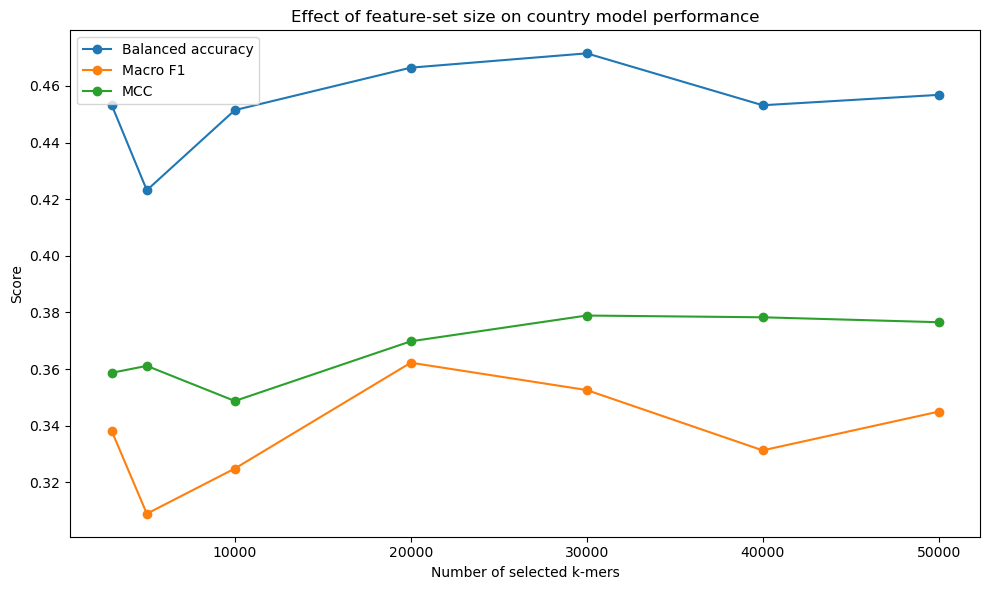

In [19]:
best_per_feature = (
    model_comparison_grid
    .sort_values(by=["Balanced_accuracy", "Macro_F1", "MCC"], ascending=False)
    .groupby("Top_kmers", as_index=False)
    .first()
)

display(best_per_feature)

best_per_feature.to_csv(
    "outputs/tables/best_result_per_feature_size.csv",
    index=False
)

plt.figure(figsize=(10, 6))
plt.plot(best_per_feature["Top_kmers"], best_per_feature["Balanced_accuracy"], marker="o", label="Balanced accuracy")
plt.plot(best_per_feature["Top_kmers"], best_per_feature["Macro_F1"], marker="o", label="Macro F1")
plt.plot(best_per_feature["Top_kmers"], best_per_feature["MCC"], marker="o", label="MCC")
plt.xlabel("Number of selected k-mers")
plt.ylabel("Score")
plt.title("Effect of feature-set size on country model performance")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/feature_size_performance_trend.png", dpi=300)
plt.show()

## 19. Export best tuned model: report, predictions, confusion matrix and important k-mers

,precision,recall,f1-score,support
Cyprus,0.750000,0.333333,0.461538,9.000000
Egypt,0.846154,1.000000,0.916667,11.000000
France,0.000000,0.000000,0.000000,3.000000
Greece,0.600000,0.600000,0.600000,5.000000
Italy,0.000000,0.000000,0.000000,2.000000
Morocco,0.333333,0.666667,0.444444,3.000000
Portugal,0.000000,0.000000,0.000000,9.000000
Spain,0.500000,0.090909,0.153846,11.000000
Turkey,0.542373,0.864865,0.666667,37.000000
UK,0.895522,0.898876,0.897196,267.000000


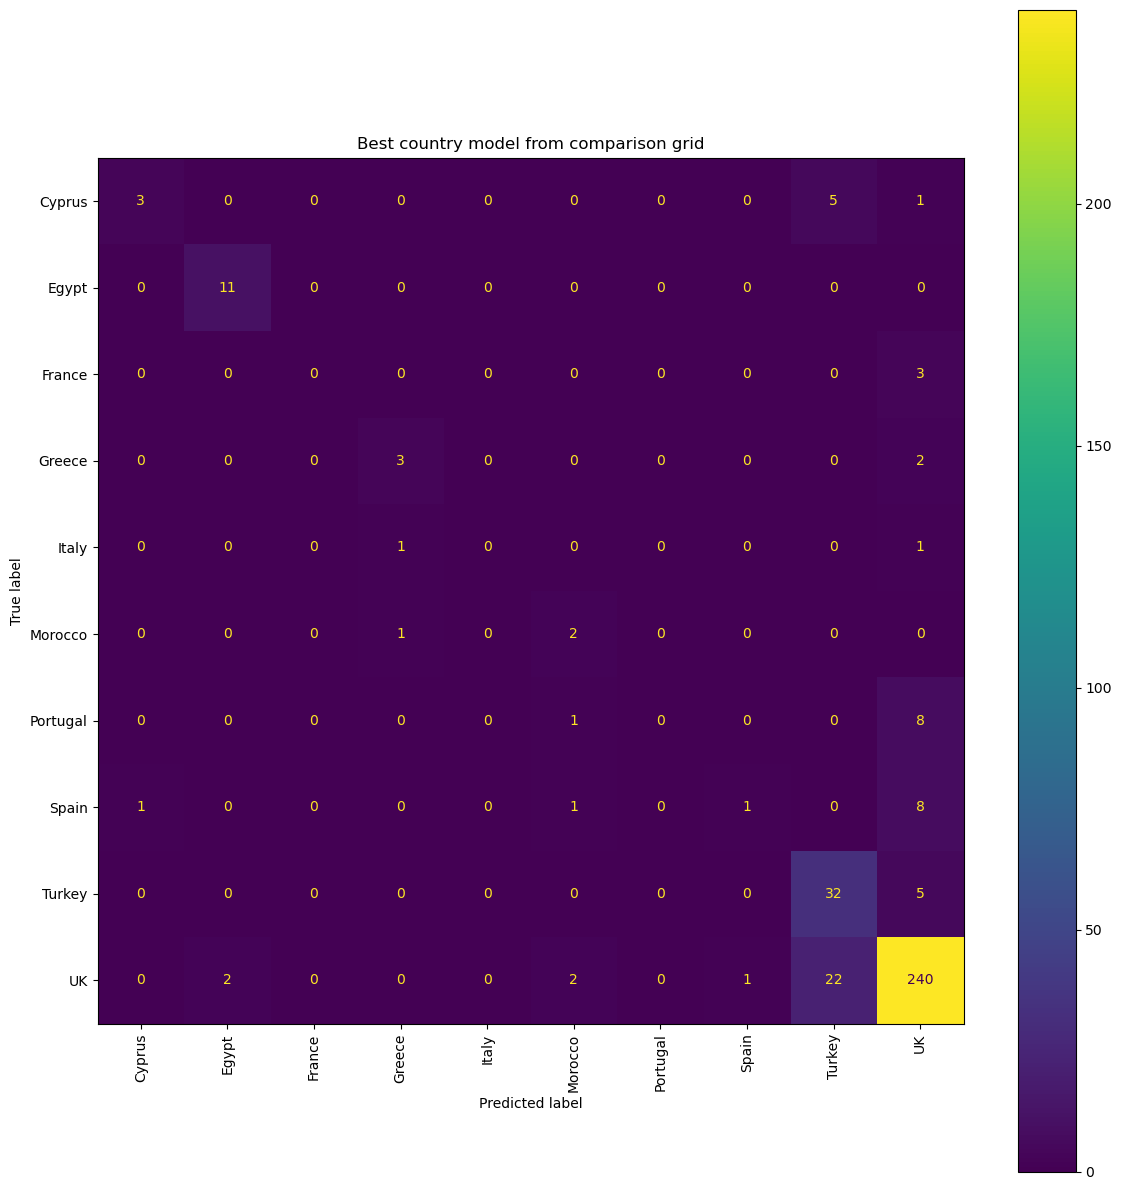

,kmer,importance
6872,TTTTTTTGAACAGAGGGGGCAATTTTCACCCTCTATCATCCCAGGC...,0.001563
21244,TTTTTTCGCTTTGATCGCATCAACAATGGGTTTGTTCGCCGGAACC...,0.001417
43294,TTTTTGCGCTTTCGGCAGGAACTGCTCATAAACGCGACCGCCGCCA...,0.001311
49610,TTTTTGAACAGAGGGGTCAATTTTCACCCTCTATCATCCCAGGCAG...,0.001257
21243,TTTTTTCGCTTTGATCGCATCAACAATGGGTTTGTTCGCCGGAACC...,0.001174
49611,TTTTTGAACAGAGGGGGCAATTTTCACCCTCTATCATCCCAGGCAG...,0.001152
18871,TTTTTTCTTCTGCCTTAAAGTTTTTCACCGTTAAAAAAAGATTTTG...,0.001092
32938,TTTTTTAAGAAATGCTGAAGGTTCCAGAGTATGTAGTTTATATGAT...,0.001081
16960,TTTTTTGATGGGGTTCAGCGAGGCGCTTCGCGATCGTTATGATTTT...,0.001009
18212,TTTTTTGAACAGAGGGGTCAATTTTCACCCTCTATCATCCCAGGCA...,0.000982


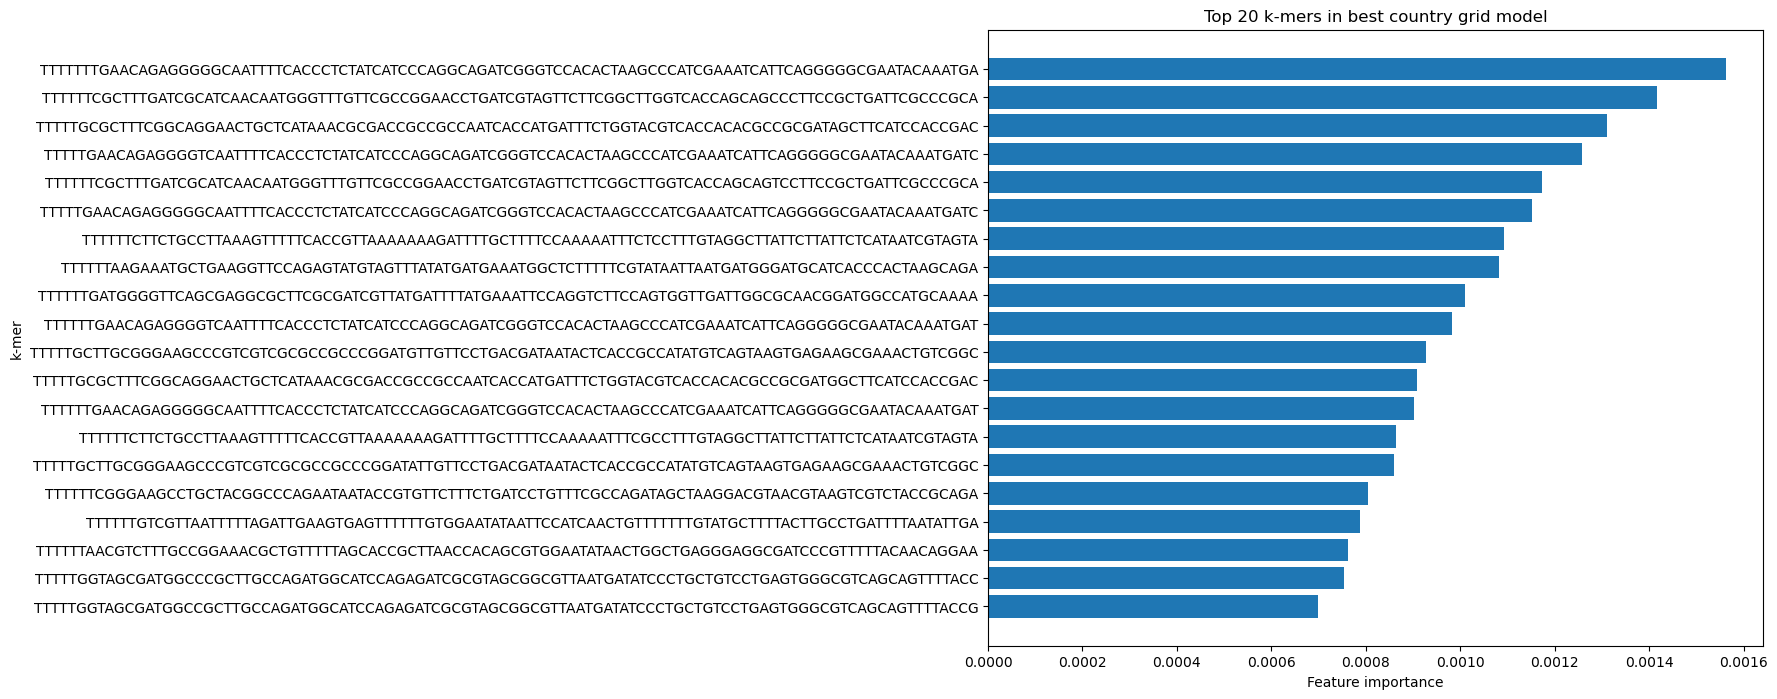

In [20]:
best_grid_report = classification_report(
    y_test_country_grid,
    best_predictions,
    output_dict=True,
    zero_division=0
)

best_grid_report_df = pd.DataFrame(best_grid_report).transpose()

display(best_grid_report_df)

best_grid_report_df.to_csv(
    "outputs/tables/best_grid_country_classification_report.csv"
)

best_grid_predictions_df = pd.DataFrame({
    "True_country": y_test_country_grid,
    "Predicted_country": best_predictions
})

best_grid_predictions_df.to_csv(
    "outputs/tables/best_grid_country_predictions.csv",
    index=True
)

# Confusion matrix for best grid country model

country_labels = sorted(y_test_country_grid.unique())

cm = confusion_matrix(
    y_test_country_grid,
    best_predictions,
    labels=country_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=country_labels
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Best country model from comparison grid")
plt.tight_layout()
plt.savefig("outputs/figures/best_grid_country_confusion_matrix.png", dpi=300)
plt.show()

# Feature importance for best grid country model

best_grid_importance = pd.DataFrame({
    "kmer": best_features,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

display(best_grid_importance.head(20))

best_grid_importance.to_csv(
    "outputs/tables/best_grid_country_feature_importance_all.csv",
    index=False
)

best_grid_importance.head(20).to_csv(
    "outputs/tables/best_grid_country_top20_kmers.csv",
    index=False
)

# Top 20 k-mer plot

top20 = best_grid_importance.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20["kmer"], top20["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.ylabel("k-mer")
plt.title("Top 20 k-mers in best country grid model")
plt.tight_layout()
plt.savefig("outputs/figures/best_grid_country_top20_kmers.png", dpi=300)
plt.show()

# Save best model

with open("outputs/models/best_grid_country_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

## 20. Region model comparison grid

In [21]:
# Filter region data before grid search
X_train_region_grid, X_test_region_grid, y_train_region_grid, y_test_region_grid = filter_classes(
    X_train_region,
    X_test_region,
    y_train_region,
    y_test_region,
    min_samples=15
)

print("Filtered region dataset for grid:")
print("Training data:", X_train_region_grid.shape)
print("Testing data:", X_test_region_grid.shape)
print("Training classes:", y_train_region_grid.nunique())
print("Testing classes:", y_test_region_grid.nunique())

print("\nTraining region counts:")
print(y_train_region_grid.value_counts())

print("\nTesting region counts:")
print(y_test_region_grid.value_counts())


region_feature_grid = [3000, 5000, 10000, 20000, 30000, 40000, 50000]

region_balancing_grid = [
    "none",
    "undersample_UK",
    "undersample_all",
    "hybrid"
]

region_model_grid = [
    {
        "Model_setting": "RF_300_balanced_default",
        "n_estimators": 300,
        "class_weight": "balanced",
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "max_depth": None
    },
    {
        "Model_setting": "RF_500_balanced_subsample_regularised",
        "n_estimators": 500,
        "class_weight": "balanced_subsample",
        "max_features": "sqrt",
        "min_samples_leaf": 2,
        "min_samples_split": 4,
        "max_depth": None
    },
    {
        "Model_setting": "RF_500_restricted_depth",
        "n_estimators": 500,
        "class_weight": "balanced_subsample",
        "max_features": "sqrt",
        "min_samples_leaf": 2,
        "min_samples_split": 6,
        "max_depth": 25
    },
    {
        "Model_setting": "RF_800_balanced_subsample_deeper",
        "n_estimators": 800,
        "class_weight": "balanced_subsample",
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "max_depth": 40
    },
    {
        "Model_setting": "RF_500_log2_features_regularised",
        "n_estimators": 500,
        "class_weight": "balanced_subsample",
        "max_features": "log2",
        "min_samples_leaf": 2,
        "min_samples_split": 4,
        "max_depth": 30
    }
]

region_target_count = 80

region_grid_results = []

best_region_score = -999
best_region_model = None
best_region_predictions = None
best_region_features = None
best_region_row = None


for top_n in region_feature_grid:

    print(f"\nSelecting top {top_n} variable k-mers for region model...")

    X_train_region_fs, X_test_region_fs, selected_region_features = select_top_variable_kmers(
        X_train_region_grid,
        X_test_region_grid,
        top_n=top_n
    )

    for balancing_strategy in region_balancing_grid:

        print(f"\nRegion balancing strategy: {balancing_strategy}")

        X_train_region_bal, y_train_region_bal = balance_training_data(
            X_train_region_fs,
            y_train_region_grid,
            strategy=balancing_strategy,
            target_count=region_target_count,
            random_state=34
        )

        for params in region_model_grid:

            print(
                f"Training region model: features={top_n}, "
                f"balancing={balancing_strategy}, "
                f"setting={params['Model_setting']}"
            )

            region_grid_model = RandomForestClassifier(
                n_estimators=params["n_estimators"],
                random_state=34,
                n_jobs=6,
                class_weight=params["class_weight"],
                max_features=params["max_features"],
                min_samples_leaf=params["min_samples_leaf"],
                min_samples_split=params["min_samples_split"],
                max_depth=params["max_depth"],
                bootstrap=True
            )

            region_grid_model.fit(X_train_region_bal, y_train_region_bal)

            region_grid_predictions = region_grid_model.predict(X_test_region_fs)

            region_metrics = evaluate_model(
                y_test_region_grid,
                region_grid_predictions
            )

            region_row = {
                "Feature_selection": f"top_{top_n}_variable_kmers",
                "Top_kmers": top_n,
                "Balancing_strategy": balancing_strategy,
                "Target_count_per_class": region_target_count,
                "Model_setting": params["Model_setting"],
                "n_estimators": params["n_estimators"],
                "class_weight": str(params["class_weight"]),
                "max_features": params["max_features"],
                "min_samples_leaf": params["min_samples_leaf"],
                "min_samples_split": params["min_samples_split"],
                "max_depth": params["max_depth"],
                "Training_samples": X_train_region_bal.shape[0],
                "Testing_samples": X_test_region_fs.shape[0],
                "Classes": y_train_region_bal.nunique(),
                **region_metrics
            }

            region_grid_results.append(region_row)

            region_combined_score = (
                region_metrics["Balanced_accuracy"] +
                region_metrics["Macro_F1"] +
                region_metrics["MCC"]
            )

            if region_combined_score > best_region_score:
                best_region_score = region_combined_score
                best_region_model = region_grid_model
                best_region_predictions = region_grid_predictions
                best_region_features = selected_region_features
                best_region_row = region_row

            gc.collect()


# Save and display full region grid results
region_model_comparison_grid = pd.DataFrame(region_grid_results)

region_model_comparison_grid = region_model_comparison_grid.sort_values(
    by=["Balanced_accuracy", "Macro_F1", "MCC"],
    ascending=False
)

display(region_model_comparison_grid)

region_model_comparison_grid.to_csv(
    "outputs/tables/model_comparison_grid_region.csv",
    index=False
)

top10_region_grid = region_model_comparison_grid.head(10)

display(top10_region_grid)

top10_region_grid.to_csv(
    "outputs/tables/top10_model_comparison_grid_region.csv",
    index=False
)

print("\nBest region model from grid:")
print(best_region_row)

Filtered region dataset for grid:
Training data: (2429, 49999)
Testing data: (406, 49999)
Training classes: 8
Testing classes: 8

Training region counts:
Region
UK                   1907
S. Europe             193
M. East               112
N. Africa              72
C. Europe              49
Asia                   47
Subsaharan Africa      25
C. America             24
Name: count, dtype: int64

Testing region counts:
Region
UK                   267
M. East               45
S. Europe             44
N. Africa             19
C. Europe             13
Asia                  10
C. America             5
Subsaharan Africa      3
Name: count, dtype: int64

Selecting top 3000 variable k-mers for region model...

Region balancing strategy: none
Training region model: features=3000, balancing=none, setting=RF_300_balanced_default
Training region model: features=3000, balancing=none, setting=RF_500_balanced_subsample_regularised
Training region model: features=3000, balancing=none, setting=RF_500_rest

,Feature_selection,Top_kmers,Balancing_strategy,Target_count_per_class,Model_setting,n_estimators,class_weight,max_features,min_samples_leaf,min_samples_split,...,Training_samples,Testing_samples,Classes,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
135,top_50000_variable_kmers,50000,hybrid,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,640,406,8,0.549261,0.599096,0.466716,0.599096,0.469282,0.576004,0.429150
91,top_30000_variable_kmers,30000,undersample_all,80,RF_500_balanced_subsample_regularised,500,balanced_subsample,sqrt,2,4,...,457,406,8,0.551724,0.596289,0.430553,0.596289,0.449906,0.580614,0.421715
138,top_50000_variable_kmers,50000,hybrid,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,640,406,8,0.544335,0.595787,0.460514,0.595787,0.464433,0.571203,0.423348
132,top_50000_variable_kmers,50000,undersample_all,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,457,406,8,0.554187,0.592292,0.452801,0.592292,0.458238,0.581155,0.423187
111,top_40000_variable_kmers,40000,undersample_all,80,RF_500_balanced_subsample_regularised,500,balanced_subsample,sqrt,2,4,...,457,406,8,0.541872,0.591980,0.419914,0.591980,0.445394,0.570206,0.411382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,top_10000_variable_kmers,10000,none,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,2429,406,8,0.716749,0.300879,0.554555,0.300879,0.346006,0.643038,0.363973
23,top_5000_variable_kmers,5000,none,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,2429,406,8,0.716749,0.298506,0.552187,0.298506,0.341834,0.639729,0.364694
3,top_3000_variable_kmers,3000,none,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,2429,406,8,0.716749,0.257244,0.555028,0.257244,0.303780,0.637413,0.365512
20,top_5000_variable_kmers,5000,none,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,2429,406,8,0.714286,0.256776,0.549788,0.256776,0.302477,0.635253,0.355999


,Feature_selection,Top_kmers,Balancing_strategy,Target_count_per_class,Model_setting,n_estimators,class_weight,max_features,min_samples_leaf,min_samples_split,...,Training_samples,Testing_samples,Classes,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
135,top_50000_variable_kmers,50000,hybrid,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,640,406,8,0.549261,0.599096,0.466716,0.599096,0.469282,0.576004,0.429150
91,top_30000_variable_kmers,30000,undersample_all,80,RF_500_balanced_subsample_regularised,500,balanced_subsample,sqrt,2,4,...,457,406,8,0.551724,0.596289,0.430553,0.596289,0.449906,0.580614,0.421715
138,top_50000_variable_kmers,50000,hybrid,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,640,406,8,0.544335,0.595787,0.460514,0.595787,0.464433,0.571203,0.423348
132,top_50000_variable_kmers,50000,undersample_all,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,457,406,8,0.554187,0.592292,0.452801,0.592292,0.458238,0.581155,0.423187
111,top_40000_variable_kmers,40000,undersample_all,80,RF_500_balanced_subsample_regularised,500,balanced_subsample,sqrt,2,4,...,457,406,8,0.541872,0.591980,0.419914,0.591980,0.445394,0.570206,0.411382
93,top_30000_variable_kmers,30000,undersample_all,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,457,406,8,0.534483,0.590983,0.453620,0.590983,0.453589,0.562848,0.412556
70,top_20000_variable_kmers,20000,undersample_all,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,457,406,8,0.514778,0.587174,0.448137,0.587174,0.443417,0.540495,0.400043
133,top_50000_variable_kmers,50000,undersample_all,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,457,406,8,0.532020,0.586050,0.456146,0.586050,0.453650,0.556687,0.412595
125,top_50000_variable_kmers,50000,undersample_UK,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,602,406,8,0.463054,0.585964,0.552678,0.585964,0.495389,0.484760,0.380418
90,top_30000_variable_kmers,30000,undersample_all,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,457,406,8,0.536946,0.584676,0.466265,0.584676,0.460470,0.562261,0.409946



Best region model from grid:
{'Feature_selection': 'top_50000_variable_kmers', 'Top_kmers': 50000, 'Balancing_strategy': 'none', 'Target_count_per_class': 80, 'Model_setting': 'RF_500_restricted_depth', 'n_estimators': 500, 'class_weight': 'balanced_subsample', 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 6, 'max_depth': 25, 'Training_samples': 2429, 'Testing_samples': 406, 'Classes': 8, 'Accuracy': 0.7413793103448276, 'Balanced_accuracy': 0.5326829053396174, 'Macro_precision': 0.6665178614280172, 'Macro_recall': 0.5326829053396174, 'Macro_F1': 0.5493109365938068, 'Weighted_F1': 0.7252313598285047, 'MCC': 0.5167210787114319}


## 21. Export best tuned region model outputs

,precision,recall,f1-score,support
Asia,0.857143,0.600000,0.705882,10.000000
C. America,1.000000,0.200000,0.333333,5.000000
C. Europe,0.000000,0.000000,0.000000,13.000000
M. East,0.550725,0.844444,0.666667,45.000000
N. Africa,0.555556,0.789474,0.652174,19.000000
S. Europe,0.538462,0.318182,0.400000,44.000000
Subsaharan Africa,1.000000,0.666667,0.800000,3.000000
UK,0.830258,0.842697,0.836431,267.000000
accuracy,0.741379,0.741379,0.741379,0.741379
macro avg,0.666518,0.532683,0.549311,406.000000


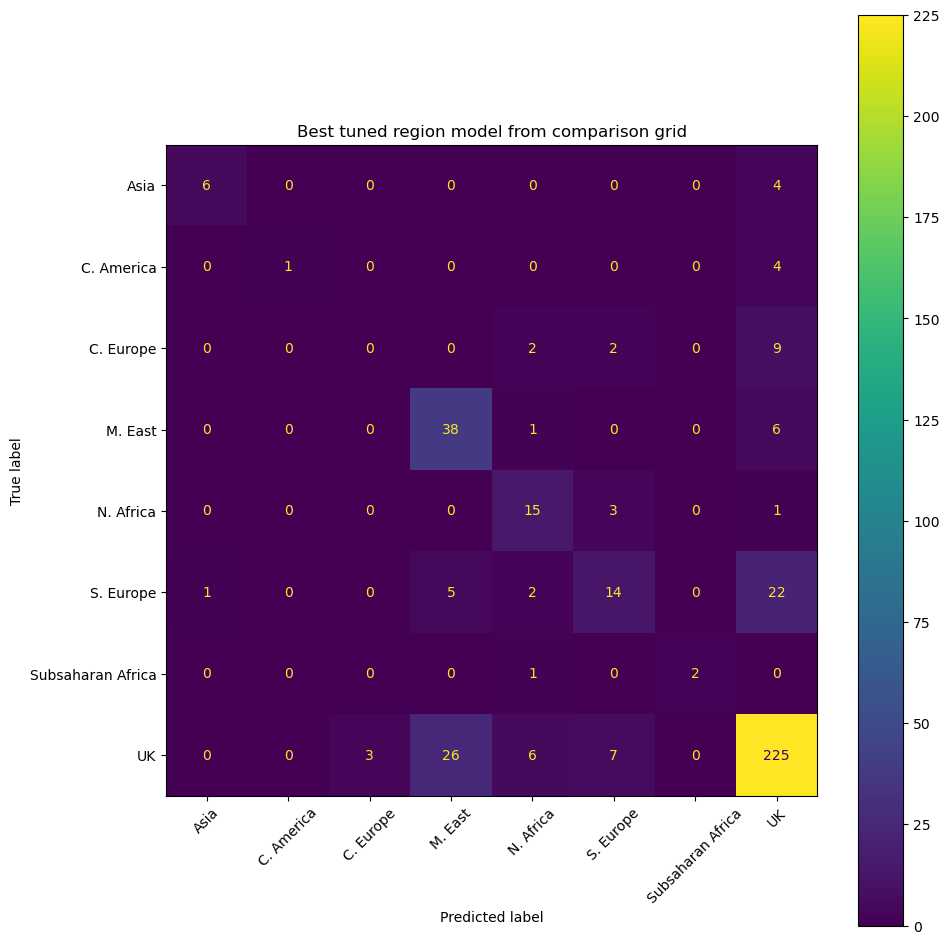

,kmer,importance
46672,TTTTTGATCGCTGA,0.001071
42763,TTTTTGCGTTGGTTGATTTCCTCAATAATCAACGCAAACCGTTTTT...,0.001055
22531,TTTTTTCCGCTGGTAATCCCAGCGAACGACGCGCTACTGCCTCAGG...,0.000988
22529,TTTTTTCCGCTGGTAATCCCAGCGAACGACGCGCTACTGCCTCAGG...,0.000907
17459,TTTTTTGAGCATG,0.000879
17460,TTTTTTGAGCATGGCT,0.000836
38827,TTTTTGTAGACCACGCTGCATTTGATGTTAGTGGGTTTGATCACTC...,0.000832
17620,TTTTTTGACGTAGAT,0.000780
15564,TTTTTTGCTCCAGCCGTTGCTTTTGCTCTGCCAGGTCGGCAGCCAA...,0.000775
17786,TTTTTTGACCAATAATCTGATAATGCTTTATTGTAAAGTCCTGCAA...,0.000769


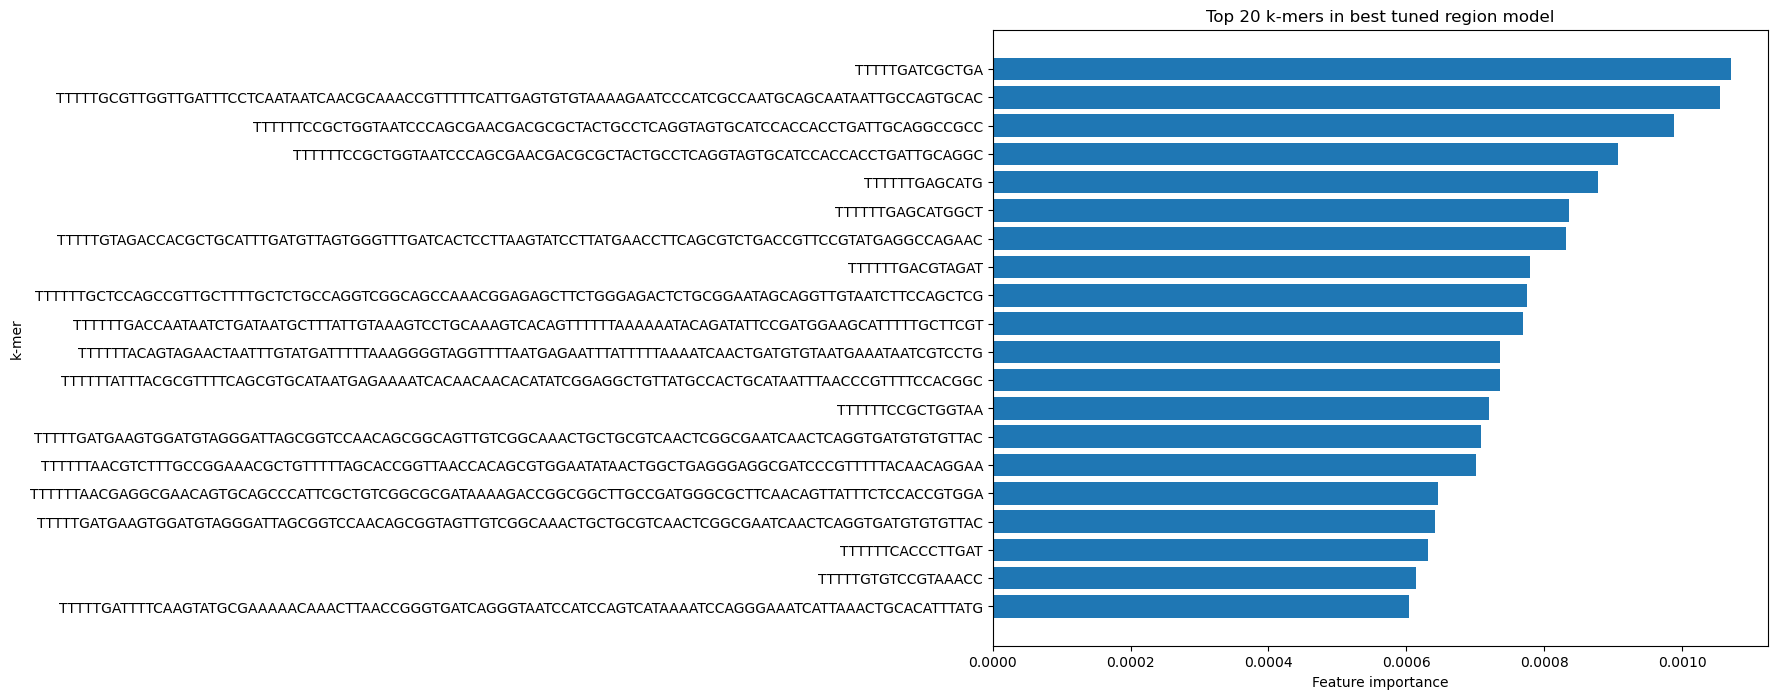

In [22]:
best_region_report = classification_report(
    y_test_region_grid,
    best_region_predictions,
    output_dict=True,
    zero_division=0
)

best_region_report_df = pd.DataFrame(best_region_report).transpose()

display(best_region_report_df)

best_region_report_df.to_csv(
    "outputs/tables/best_grid_region_classification_report.csv"
)

best_region_predictions_df = pd.DataFrame({
    "True_region": y_test_region_grid,
    "Predicted_region": best_region_predictions
})

best_region_predictions_df.to_csv(
    "outputs/tables/best_grid_region_predictions.csv",
    index=True
)

# Confusion matrix for best tuned region model
region_labels = sorted(y_test_region_grid.unique())

cm_region_best = confusion_matrix(
    y_test_region_grid,
    best_region_predictions,
    labels=region_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_region_best,
    display_labels=region_labels
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Best tuned region model from comparison grid")
plt.tight_layout()
plt.savefig("outputs/figures/best_grid_region_confusion_matrix.png", dpi=300)
plt.show()

# Feature importance for best tuned region model
best_region_importance = pd.DataFrame({
    "kmer": best_region_features,
    "importance": best_region_model.feature_importances_
}).sort_values("importance", ascending=False)

display(best_region_importance.head(20))

best_region_importance.to_csv(
    "outputs/tables/best_grid_region_feature_importance_all.csv",
    index=False
)

best_region_importance.head(20).to_csv(
    "outputs/tables/best_grid_region_top20_kmers.csv",
    index=False
)

# Top 20 k-mer plot for region model
top20_region = best_region_importance.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20_region["kmer"], top20_region["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.ylabel("k-mer")
plt.title("Top 20 k-mers in best tuned region model")
plt.tight_layout()
plt.savefig("outputs/figures/best_grid_region_top20_kmers.png", dpi=300)
plt.show()

# Save best tuned region model
with open("outputs/models/best_grid_region_model.pkl", "wb") as f:
    pickle.dump(best_region_model, f)

## 22. Train and evaluate tuned region model

Filtered region dataset:
Training data: (2429, 49999)
Testing data: (406, 49999)
Training classes: 8
Testing classes: 8

Training region counts:
Region
UK                   1907
S. Europe             193
M. East               112
N. Africa              72
C. Europe              49
Asia                   47
Subsaharan Africa      25
C. America             24
Name: count, dtype: int64

Testing region counts:
Region
UK                   267
M. East               45
S. Europe             44
N. Africa             19
C. Europe             13
Asia                  10
C. America             5
Subsaharan Africa      3
Name: count, dtype: int64

Region feature-selected training shape: (2429, 10000)
Region feature-selected testing shape: (406, 10000)

TUNED REGION MODEL
Accuracy: 0.7339901477832512
Balanced accuracy: 0.3746877034687502
Macro precision: 0.5253489326765188
Macro recall: 0.3746877034687502
Macro F1: 0.41988245018442594
Weighted F1: 0.6800071879322663
MCC: 0.4219801455661224
        

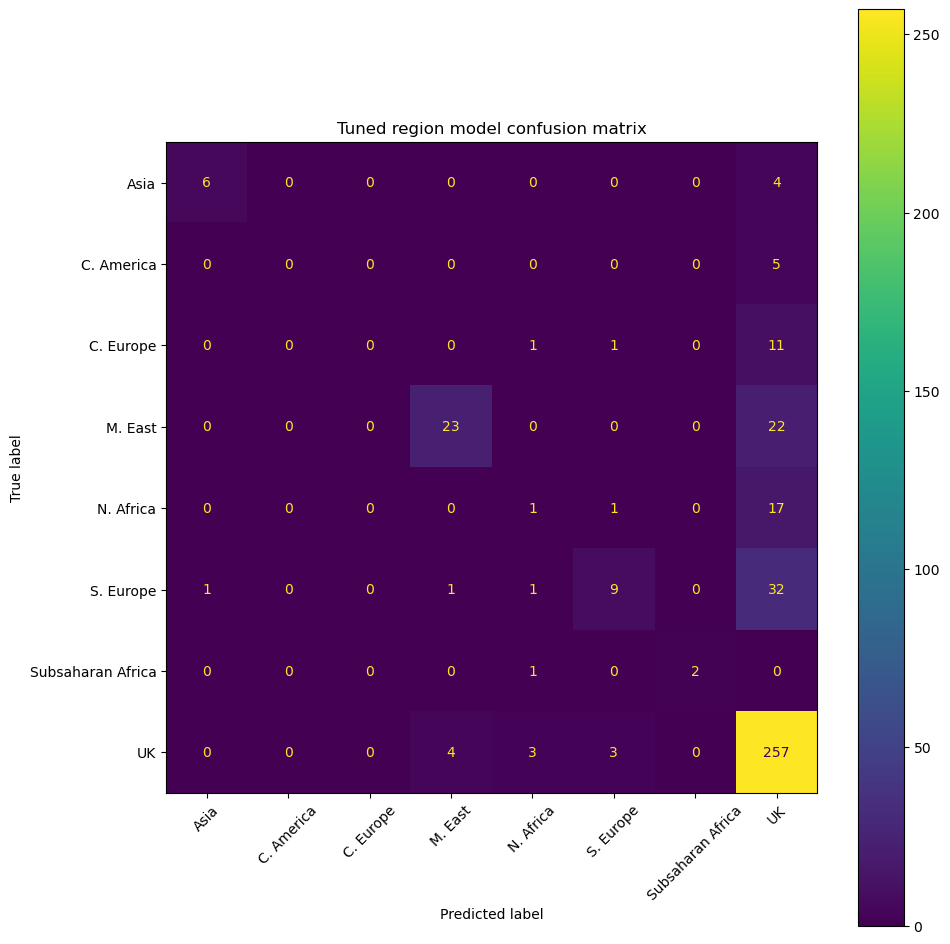

,kmer,importance
9853,TTTTTTCCGCTGGTAATCCCAGCGAACGACGCGCTACTGCCTCAGG...,0.003038
9900,TTTTTTCCGCTGGTAATCCCAGCGAACGACGCGCTACTGCCTCAGG...,0.002099
4246,TTTTTTGATTCT,0.001747
1883,TTTTTGTGTCCGTAA,0.001661
1367,TTTTTGTGTCCG,0.001603
9618,TTTTTTCCGCTGGTAATCCCAGCGAAC,0.001581
9947,TTTTTTCCGCTGGTAATCCCAGCGAACGACGCGCTACTGCCTCAGG...,0.001475
1799,TTTTTGTGTCCGT,0.001405
9452,TTTTTTCCGCTGGTAATCCCAGCGAACGACGCGCTACTGCCTCAGGTA,0.001349
9831,TTTTTTCCGCTGGTAATCCCAGCGAACGACGCGCTACTGCCTCAGG...,0.001340


In [23]:
X_train_region_grid, X_test_region_grid, y_train_region_grid, y_test_region_grid = filter_classes(
    X_train_region,
    X_test_region,
    y_train_region,
    y_test_region,
    min_samples=15
)

print("Filtered region dataset:")
print("Training data:", X_train_region_grid.shape)
print("Testing data:", X_test_region_grid.shape)
print("Training classes:", y_train_region_grid.nunique())
print("Testing classes:", y_test_region_grid.nunique())

print("\nTraining region counts:")
print(y_train_region_grid.value_counts())

print("\nTesting region counts:")
print(y_test_region_grid.value_counts())

# Select top 10,000 variable k-mers for region model
X_train_region_fs, X_test_region_fs, region_features = select_top_variable_kmers(
    X_train_region_grid,
    X_test_region_grid,
    top_n=10000
)

print("\nRegion feature-selected training shape:", X_train_region_fs.shape)
print("Region feature-selected testing shape:", X_test_region_fs.shape)

tuned_region_model = RandomForestClassifier(
    n_estimators=500,
    random_state=34,
    n_jobs=6,
    class_weight="balanced_subsample",
    max_features="sqrt",
    min_samples_leaf=2,
    min_samples_split=4,
    max_depth=None,
    bootstrap=True
)

tuned_region_model.fit(X_train_region_fs, y_train_region_grid)

tuned_region_pred = tuned_region_model.predict(X_test_region_fs)

tuned_region_accuracy = accuracy_score(y_test_region_grid, tuned_region_pred)
tuned_region_balanced_accuracy = balanced_accuracy_score(y_test_region_grid, tuned_region_pred)
tuned_region_macro_precision = precision_score(y_test_region_grid, tuned_region_pred, average="macro", zero_division=0)
tuned_region_macro_recall = recall_score(y_test_region_grid, tuned_region_pred, average="macro", zero_division=0)
tuned_region_macro_f1 = f1_score(y_test_region_grid, tuned_region_pred, average="macro", zero_division=0)
tuned_region_weighted_f1 = f1_score(y_test_region_grid, tuned_region_pred, average="weighted", zero_division=0)
tuned_region_mcc = matthews_corrcoef(y_test_region_grid, tuned_region_pred)

print("\nTUNED REGION MODEL")
print("Accuracy:", tuned_region_accuracy)
print("Balanced accuracy:", tuned_region_balanced_accuracy)
print("Macro precision:", tuned_region_macro_precision)
print("Macro recall:", tuned_region_macro_recall)
print("Macro F1:", tuned_region_macro_f1)
print("Weighted F1:", tuned_region_weighted_f1)
print("MCC:", tuned_region_mcc)
print(classification_report(y_test_region_grid, tuned_region_pred, zero_division=0))

tuned_region_report_df = pd.DataFrame(
    classification_report(
        y_test_region_grid,
        tuned_region_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

tuned_region_report_df.to_csv(
    "outputs/tables/tuned_region_classification_report.csv"
)

# Save predictions
tuned_region_predictions_df = pd.DataFrame({
    "True_region": y_test_region_grid,
    "Predicted_region": tuned_region_pred
})

tuned_region_predictions_df.to_csv(
    "outputs/tables/tuned_region_predictions.csv",
    index=True
)

# Confusion matrix
region_labels = sorted(y_test_region_grid.unique())

cm_region_tuned = confusion_matrix(
    y_test_region_grid,
    tuned_region_pred,
    labels=region_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_region_tuned,
    display_labels=region_labels
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Tuned region model confusion matrix")
plt.tight_layout()
plt.savefig("outputs/figures/tuned_region_confusion_matrix.png", dpi=300)
plt.show()

# Feature importance
tuned_region_importance = pd.DataFrame({
    "kmer": region_features,
    "importance": tuned_region_model.feature_importances_
}).sort_values("importance", ascending=False)

display(tuned_region_importance.head(20))

tuned_region_importance.to_csv(
    "outputs/tables/tuned_region_feature_importance_all.csv",
    index=False
)

tuned_region_importance.head(20).to_csv(
    "outputs/tables/tuned_region_top20_kmers.csv",
    index=False
)

# Save tuned region model
with open("outputs/models/tuned_region_model.pkl", "wb") as f:
    pickle.dump(tuned_region_model, f)

## 23. Effect of feature-set size on region model performance

,Top_kmers,Feature_selection,Balancing_strategy,Target_count_per_class,Model_setting,n_estimators,class_weight,max_features,min_samples_leaf,min_samples_split,...,Training_samples,Testing_samples,Classes,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
0,3000,top_3000_variable_kmers,undersample_all,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,457,406,8,0.502463,0.548333,0.413963,0.548333,0.407004,0.530933,0.380886
1,5000,top_5000_variable_kmers,undersample_all,80,RF_500_restricted_depth,500,balanced_subsample,sqrt,2,6,...,457,406,8,0.507389,0.565318,0.373236,0.565318,0.396678,0.539301,0.383240
2,10000,top_10000_variable_kmers,undersample_all,80,RF_800_balanced_subsample_deeper,800,balanced_subsample,sqrt,1,2,...,457,406,8,0.509852,0.556729,0.409028,0.556729,0.421510,0.532530,0.389069
3,20000,top_20000_variable_kmers,undersample_all,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,457,406,8,0.514778,0.587174,0.448137,0.587174,0.443417,0.540495,0.400043
4,30000,top_30000_variable_kmers,undersample_all,80,RF_500_balanced_subsample_regularised,500,balanced_subsample,sqrt,2,4,...,457,406,8,0.551724,0.596289,0.430553,0.596289,0.449906,0.580614,0.421715
5,40000,top_40000_variable_kmers,undersample_all,80,RF_500_balanced_subsample_regularised,500,balanced_subsample,sqrt,2,4,...,457,406,8,0.541872,0.591980,0.419914,0.591980,0.445394,0.570206,0.411382
6,50000,top_50000_variable_kmers,hybrid,80,RF_300_balanced_default,300,balanced,sqrt,1,2,...,640,406,8,0.549261,0.599096,0.466716,0.599096,0.469282,0.576004,0.429150


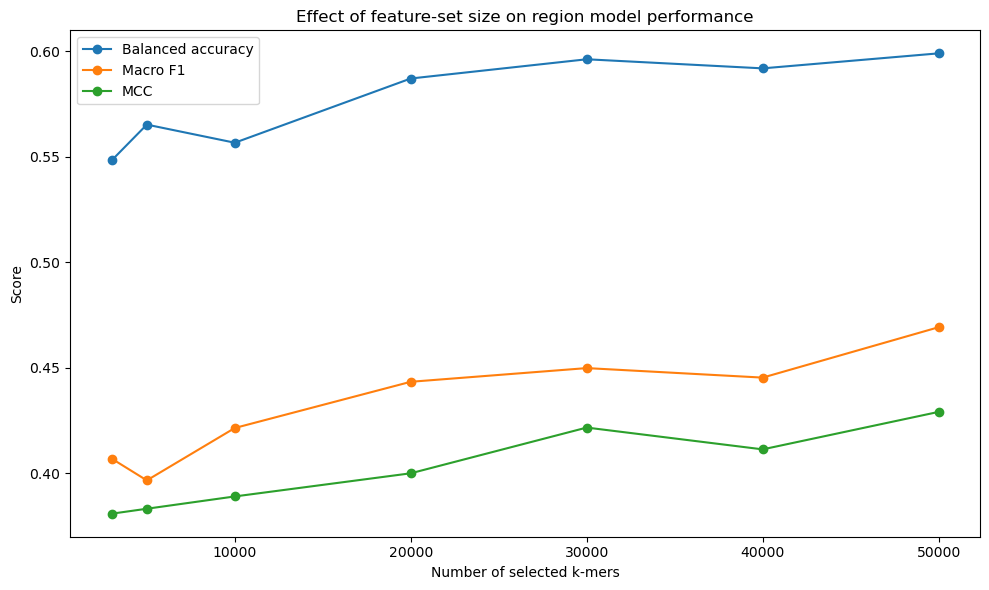

In [24]:
best_region_per_feature = (
    region_model_comparison_grid
    .sort_values(by=["Balanced_accuracy", "Macro_F1", "MCC"], ascending=False)
    .groupby("Top_kmers", as_index=False)
    .first()
)

display(best_region_per_feature)

best_region_per_feature.to_csv(
    "outputs/tables/best_region_result_per_feature_size.csv",
    index=False
)

plt.figure(figsize=(10, 6))

plt.plot(
    best_region_per_feature["Top_kmers"],
    best_region_per_feature["Balanced_accuracy"],
    marker="o",
    label="Balanced accuracy"
)

plt.plot(
    best_region_per_feature["Top_kmers"],
    best_region_per_feature["Macro_F1"],
    marker="o",
    label="Macro F1"
)

plt.plot(
    best_region_per_feature["Top_kmers"],
    best_region_per_feature["MCC"],
    marker="o",
    label="MCC"
)

plt.xlabel("Number of selected k-mers")
plt.ylabel("Score")
plt.title("Effect of feature-set size on region model performance")
plt.legend()
plt.tight_layout()

plt.savefig(
    "outputs/figures/feature_size_performance_trend_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 24. Hierarchical model: predict region first, then country

In [25]:
# Use samples that have both country and region labels
hier_train_keep = train_meta["Country"].notna() & train_meta["Region"].notna()
hier_test_keep = test_meta["Country"].notna() & test_meta["Region"].notna()

X_train_hier = train_kmers.loc[hier_train_keep].copy()
X_test_hier = test_kmers.loc[hier_test_keep].copy()

y_train_hier_country = train_meta.loc[hier_train_keep, "Country"].astype(str)
y_test_hier_country = test_meta.loc[hier_test_keep, "Country"].astype(str)

y_train_hier_region = train_meta.loc[hier_train_keep, "Region"].astype(str)
y_test_hier_region = test_meta.loc[hier_test_keep, "Region"].astype(str)

# Align features between train and test
X_train_hier, X_test_hier = X_train_hier.align(
    X_test_hier,
    join="inner",
    axis=1
)

print("Initial hierarchical dataset:")
print("Training data:", X_train_hier.shape)
print("Testing data:", X_test_hier.shape)
print("Training countries:", y_train_hier_country.nunique())
print("Testing countries:", y_test_hier_country.nunique())
print("Training regions:", y_train_hier_region.nunique())
print("Testing regions:", y_test_hier_region.nunique())

Initial hierarchical dataset:
Training data: (2459, 49999)
Testing data: (415, 49999)
Training countries: 70
Testing countries: 41
Training regions: 12
Testing regions: 11


## 25. Filter hierarchical dataset to shared country classes

In [26]:
min_country_samples = 15

shared_countries = set(y_train_hier_country.unique()).intersection(
    set(y_test_hier_country.unique())
)

country_counts = y_train_hier_country.value_counts()

enough_country_samples = set(
    country_counts[country_counts >= min_country_samples].index
)

valid_countries = shared_countries.intersection(enough_country_samples)

train_keep = y_train_hier_country.isin(valid_countries)
test_keep = y_test_hier_country.isin(valid_countries)

X_train_hier = X_train_hier.loc[train_keep].copy()
X_test_hier = X_test_hier.loc[test_keep].copy()

y_train_hier_country = y_train_hier_country.loc[train_keep].copy()
y_test_hier_country = y_test_hier_country.loc[test_keep].copy()

y_train_hier_region = y_train_hier_region.loc[train_keep].copy()
y_test_hier_region = y_test_hier_region.loc[test_keep].copy()

print("Filtered hierarchical dataset:")
print("Training data:", X_train_hier.shape)
print("Testing data:", X_test_hier.shape)
print("Training countries:", y_train_hier_country.nunique())
print("Testing countries:", y_test_hier_country.nunique())
print("Training regions:", y_train_hier_region.nunique())
print("Testing regions:", y_test_hier_region.nunique())

print("\nTraining country counts:")
print(y_train_hier_country.value_counts())

print("\nTesting country counts:")
print(y_test_hier_country.value_counts())

print("\nTraining region counts:")
print(y_train_hier_region.value_counts())

print("\nTesting region counts:")
print(y_test_hier_region.value_counts())

Filtered hierarchical dataset:
Training data: (2246, 49999)
Testing data: (357, 49999)
Training countries: 10
Testing countries: 10
Training regions: 6
Testing regions: 5

Training country counts:
Country
UK          1907
Spain        101
Turkey        84
Morocco       34
Egypt         23
Cyprus        21
Italy         20
Greece        20
France        19
Portugal      17
Name: count, dtype: int64

Testing country counts:
Country
UK          267
Turkey       37
Spain        11
Egypt        11
Portugal      9
Cyprus        9
Greece        5
France        3
Morocco       3
Italy         2
Name: count, dtype: int64

Training region counts:
Region
UK            1907
S. Europe      179
M. East         84
N. Africa       57
C. Europe       18
C. America       1
Name: count, dtype: int64

Testing region counts:
Region
UK           267
M. East       37
S. Europe     36
N. Africa     14
C. Europe      3
Name: count, dtype: int64


## 26. Extract best country and region grid settings

In [27]:
# Best country settings
best_country_settings = model_comparison_grid.sort_values(
    by=["Balanced_accuracy", "Macro_F1", "MCC"],
    ascending=False
).iloc[0]

# Best region settings
best_region_settings = region_model_comparison_grid.sort_values(
    by=["Balanced_accuracy", "Macro_F1", "MCC"],
    ascending=False
).iloc[0]


def clean_param(value):
    """
    Converts stored grid values into valid Random Forest parameters.
    """
    if pd.isna(value):
        return None
    if value == "None":
        return None
    return value


def make_rf_from_settings(settings, n_jobs=6):
    """
    Creates a Random Forest model using the settings from a grid row.
    """
    max_depth = clean_param(settings["max_depth"])

    if max_depth is not None:
        max_depth = int(max_depth)

    class_weight = clean_param(settings["class_weight"])

    if class_weight == "None":
        class_weight = None

    model = RandomForestClassifier(
        n_estimators=int(settings["n_estimators"]),
        random_state=34,
        n_jobs=n_jobs,
        class_weight=class_weight,
        max_features=settings["max_features"],
        min_samples_leaf=int(settings["min_samples_leaf"]),
        min_samples_split=int(settings["min_samples_split"]),
        max_depth=max_depth,
        bootstrap=True
    )

    return model


print("Best country grid settings:")
display(best_country_settings)

print("\nBest region grid settings:")
display(best_region_settings)

Best country grid settings:


Feature_selection         top_30000_variable_kmers
Top_kmers                                    30000
Balancing_strategy                  undersample_UK
Target_count_per_class                          80
Model_setting              RF_300_balanced_default
n_estimators                                   300
class_weight                              balanced
max_features                                  sqrt
min_samples_leaf                                 1
min_samples_split                                2
max_depth                                      NaN
Training_samples                               419
Testing_samples                                357
Classes                                         10
Accuracy                                  0.504202
Balanced_accuracy                         0.471517
Macro_precision                            0.37255
Macro_recall                              0.471517
Macro_F1                                    0.3526
Weighted_F1                    


Best region grid settings:


Feature_selection         top_50000_variable_kmers
Top_kmers                                    50000
Balancing_strategy                          hybrid
Target_count_per_class                          80
Model_setting              RF_300_balanced_default
n_estimators                                   300
class_weight                              balanced
max_features                                  sqrt
min_samples_leaf                                 1
min_samples_split                                2
max_depth                                      NaN
Training_samples                               640
Testing_samples                                406
Classes                                          8
Accuracy                                  0.549261
Balanced_accuracy                         0.599096
Macro_precision                           0.466716
Macro_recall                              0.599096
Macro_F1                                  0.469282
Weighted_F1                    

## 27. Stage 1: train the region model

In [28]:
region_top_kmers = int(best_region_settings["Top_kmers"])

X_train_hier_region_fs, X_test_hier_region_fs, hier_region_features = select_top_variable_kmers(
    X_train_hier,
    X_test_hier,
    top_n=region_top_kmers
)

print("Region stage feature-selected data:")
print("Training:", X_train_hier_region_fs.shape)
print("Testing:", X_test_hier_region_fs.shape)

region_balance_strategy = best_region_settings["Balancing_strategy"]

X_train_region_stage_bal, y_train_region_stage_bal = balance_training_data(
    X_train_hier_region_fs,
    y_train_hier_region,
    strategy=region_balance_strategy,
    target_count=80,
    random_state=34
)

print("\nRegion stage after balancing:")
print("Training:", X_train_region_stage_bal.shape)
print(y_train_region_stage_bal.value_counts())

hier_region_model = make_rf_from_settings(best_region_settings)

hier_region_model.fit(
    X_train_region_stage_bal,
    y_train_region_stage_bal
)

hier_predicted_region = hier_region_model.predict(X_test_hier_region_fs)

print("\nStage 1 region prediction performance:")
print(classification_report(y_test_hier_region, hier_predicted_region, zero_division=0))

hier_region_metrics = evaluate_model(
    y_test_hier_region,
    hier_predicted_region
)

print(hier_region_metrics)

Requested 50000 k-mers, but only 49999 available. Using all features.
Region stage feature-selected data:
Training: (2246, 49999)
Testing: (357, 49999)

Region stage after balancing:
Training: (480, 49999)
__label__
C. America    80
C. Europe     80
M. East       80
S. Europe     80
UK            80
N. Africa     80
Name: count, dtype: int64

Stage 1 region prediction performance:
              precision    recall  f1-score   support

   C. Europe       0.00      0.00      0.00         3
     M. East       0.36      0.95      0.53        37
   N. Africa       0.44      1.00      0.61        14
   S. Europe       0.16      0.42      0.23        36
          UK       0.98      0.47      0.64       267

    accuracy                           0.53       357
   macro avg       0.39      0.57      0.40       357
weighted avg       0.80      0.53      0.58       357

{'Accuracy': 0.5322128851540616, 'Balanced_accuracy': 0.5669045449944325, 'Macro_precision': 0.38734445124439004, 'Macro_recall

## 28. Stage 2: train country models within each region

In [29]:
country_top_kmers = int(best_country_settings["Top_kmers"])

X_train_hier_country_fs, X_test_hier_country_fs, hier_country_features = select_top_variable_kmers(
    X_train_hier,
    X_test_hier,
    top_n=country_top_kmers
)

print("Country stage feature-selected data:")
print("Training:", X_train_hier_country_fs.shape)
print("Testing:", X_test_hier_country_fs.shape)

country_balance_strategy = best_country_settings["Balancing_strategy"]

region_country_models = {}

for region in sorted(y_train_hier_region.unique()):

    region_mask = y_train_hier_region == region

    X_region_train = X_train_hier_country_fs.loc[region_mask].copy()
    y_region_country_train = y_train_hier_country.loc[region_mask].copy()

    print("\nTraining country model for region:", region)
    print("Samples:", X_region_train.shape[0])
    print("Countries:", y_region_country_train.nunique())
    print(y_region_country_train.value_counts())

    # If a region only has one country, use a constant prediction
    if y_region_country_train.nunique() == 1:
        constant_country = y_region_country_train.iloc[0]

        region_country_models[region] = {
            "type": "constant",
            "label": constant_country
        }

        print("Only one country in this region. Using constant prediction:", constant_country)

    else:
        X_region_bal, y_region_bal = balance_training_data(
            X_region_train,
            y_region_country_train,
            strategy=country_balance_strategy,
            target_count=80,
            random_state=34
        )

        model = make_rf_from_settings(best_country_settings)

        model.fit(X_region_bal, y_region_bal)

        region_country_models[region] = {
            "type": "model",
            "model": model
        }

        print("Region-specific country model trained.")

Country stage feature-selected data:
Training: (2246, 30000)
Testing: (357, 30000)

Training country model for region: C. America
Samples: 1
Countries: 1
Country
France    1
Name: count, dtype: int64
Only one country in this region. Using constant prediction: France

Training country model for region: C. Europe
Samples: 18
Countries: 1
Country
France    18
Name: count, dtype: int64
Only one country in this region. Using constant prediction: France

Training country model for region: M. East
Samples: 84
Countries: 1
Country
Turkey    84
Name: count, dtype: int64
Only one country in this region. Using constant prediction: Turkey

Training country model for region: N. Africa
Samples: 57
Countries: 2
Country
Morocco    34
Egypt      23
Name: count, dtype: int64
Region-specific country model trained.

Training country model for region: S. Europe
Samples: 179
Countries: 5
Country
Spain       101
Cyprus       21
Italy        20
Greece       20
Portugal     17
Name: count, dtype: int64
Region-

## 29. Make hierarchical country predictions

In [30]:
hierarchical_country_predictions = []

for sample_id, predicted_region in zip(X_test_hier_country_fs.index, hier_predicted_region):

    sample_features = X_test_hier_country_fs.loc[[sample_id]]

    if predicted_region in region_country_models:

        region_entry = region_country_models[predicted_region]

        if region_entry["type"] == "constant":
            country_prediction = region_entry["label"]

        else:
            country_prediction = region_entry["model"].predict(sample_features)[0]

    else:
        # Fallback if the predicted region was not seen during training
        country_prediction = y_train_hier_country.mode()[0]

    hierarchical_country_predictions.append(country_prediction)

hierarchical_country_predictions = np.array(hierarchical_country_predictions)

print("Hierarchical country predictions complete.")
print(pd.Series(hierarchical_country_predictions).value_counts())

Hierarchical country predictions complete.
UK         129
Turkey      96
Spain       90
Morocco     19
Egypt       13
France       5
Cyprus       3
Greece       2
Name: count, dtype: int64


## 30. Evaluate hierarchical model

In [31]:
hierarchical_accuracy = accuracy_score(
    y_test_hier_country,
    hierarchical_country_predictions
)

hierarchical_balanced_accuracy = balanced_accuracy_score(
    y_test_hier_country,
    hierarchical_country_predictions
)

hierarchical_macro_precision = precision_score(
    y_test_hier_country,
    hierarchical_country_predictions,
    average="macro",
    zero_division=0
)

hierarchical_macro_recall = recall_score(
    y_test_hier_country,
    hierarchical_country_predictions,
    average="macro",
    zero_division=0
)

hierarchical_macro_f1 = f1_score(
    y_test_hier_country,
    hierarchical_country_predictions,
    average="macro",
    zero_division=0
)

hierarchical_weighted_f1 = f1_score(
    y_test_hier_country,
    hierarchical_country_predictions,
    average="weighted",
    zero_division=0
)

hierarchical_mcc = matthews_corrcoef(
    y_test_hier_country,
    hierarchical_country_predictions
)

print("HIERARCHICAL REGION-COUNTRY MODEL")
print("Accuracy:", hierarchical_accuracy)
print("Balanced accuracy:", hierarchical_balanced_accuracy)
print("Macro precision:", hierarchical_macro_precision)
print("Macro recall:", hierarchical_macro_recall)
print("Macro F1:", hierarchical_macro_f1)
print("Weighted F1:", hierarchical_weighted_f1)
print("MCC:", hierarchical_mcc)

print("\nClassification report:")
print(
    classification_report(
        y_test_hier_country,
        hierarchical_country_predictions,
        zero_division=0
    )
)

hierarchical_report_df = pd.DataFrame(
    classification_report(
        y_test_hier_country,
        hierarchical_country_predictions,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(hierarchical_report_df)

hierarchical_report_df.to_csv(
    "outputs/tables/hierarchical_country_classification_report.csv"
)

HIERARCHICAL REGION-COUNTRY MODEL
Accuracy: 0.5182072829131653
Balanced accuracy: 0.45855328259822636
Macro precision: 0.4078709435709129
Macro recall: 0.45855328259822636
Macro F1: 0.33756471511812836
Weighted F1: 0.5810878538413012
MCC: 0.3772599038444014

Classification report:
              precision    recall  f1-score   support

      Cyprus       0.67      0.22      0.33         9
       Egypt       0.85      1.00      0.92        11
      France       0.00      0.00      0.00         3
      Greece       1.00      0.40      0.57         5
       Italy       0.00      0.00      0.00         2
     Morocco       0.16      1.00      0.27         3
    Portugal       0.00      0.00      0.00         9
       Spain       0.07      0.55      0.12        11
      Turkey       0.36      0.95      0.53        37
          UK       0.98      0.47      0.64       267

    accuracy                           0.52       357
   macro avg       0.41      0.46      0.34       357
weighted avg  

,precision,recall,f1-score,support
Cyprus,0.666667,0.222222,0.333333,9.000000
Egypt,0.846154,1.000000,0.916667,11.000000
France,0.000000,0.000000,0.000000,3.000000
Greece,1.000000,0.400000,0.571429,5.000000
Italy,0.000000,0.000000,0.000000,2.000000
Morocco,0.157895,1.000000,0.272727,3.000000
Portugal,0.000000,0.000000,0.000000,9.000000
Spain,0.066667,0.545455,0.118812,11.000000
Turkey,0.364583,0.945946,0.526316,37.000000
UK,0.976744,0.471910,0.636364,267.000000


## 31. Save hierarchical predictions and confusion matrix

,True_region,Predicted_region,True_country,Predicted_country
SRR10002237,M. East,M. East,Turkey,Turkey
SRR10010915,S. Europe,N. Africa,Spain,Morocco
SRR10010916,UK,UK,UK,UK
SRR10010917,UK,UK,UK,UK
SRR10010918,UK,UK,UK,UK


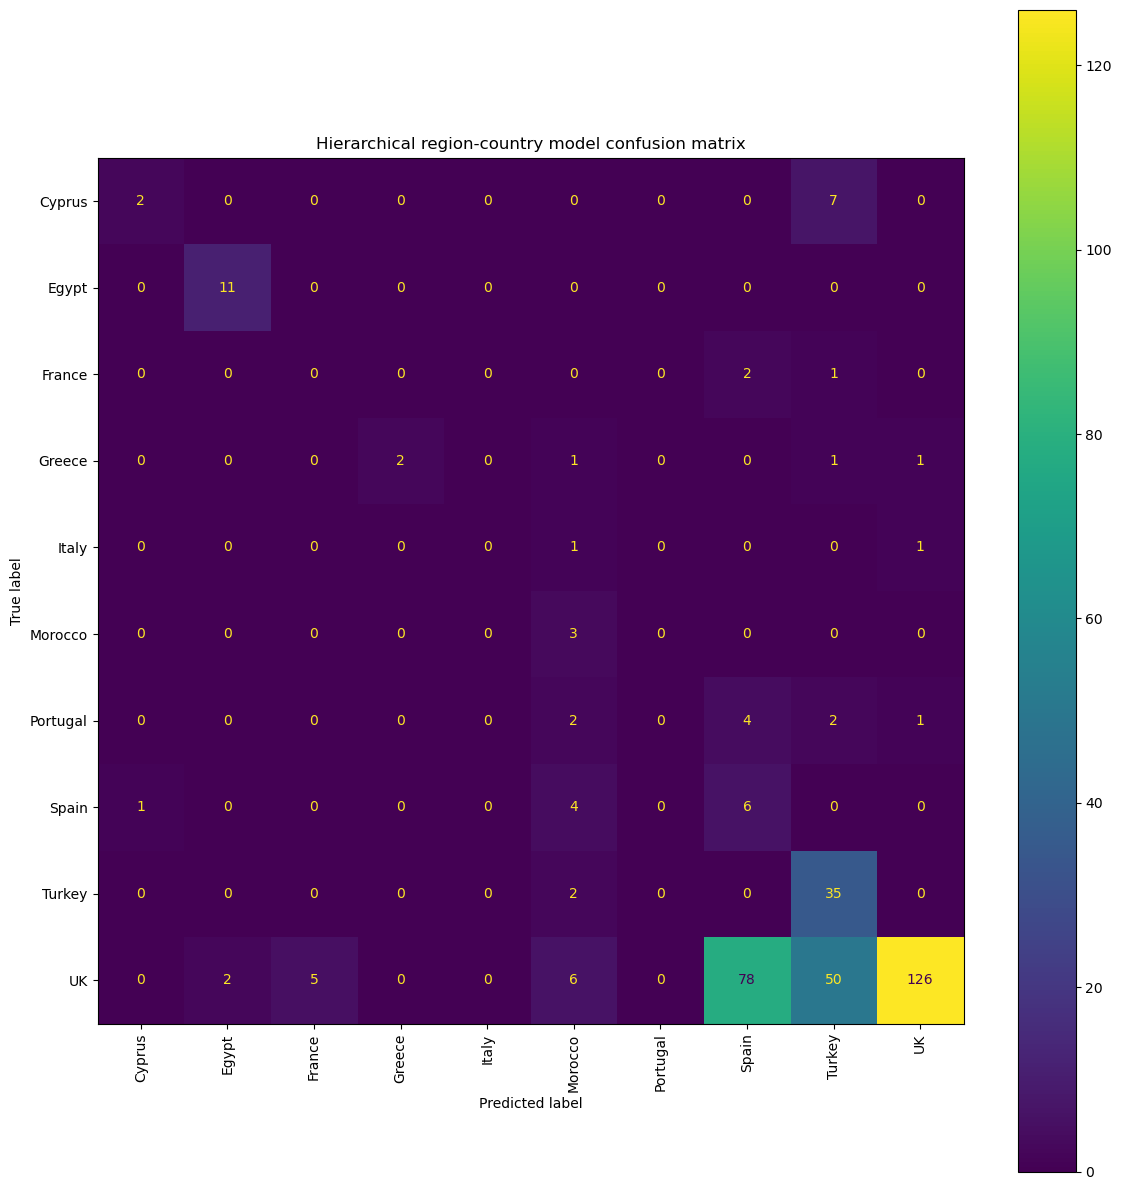

In [32]:
hierarchical_predictions_df = pd.DataFrame({
    "True_region": y_test_hier_region,
    "Predicted_region": hier_predicted_region,
    "True_country": y_test_hier_country,
    "Predicted_country": hierarchical_country_predictions
})

display(hierarchical_predictions_df.head())

hierarchical_predictions_df.to_csv(
    "outputs/tables/hierarchical_region_country_predictions.csv",
    index=True
)

hier_country_labels = sorted(y_test_hier_country.unique())

cm_hier_country = confusion_matrix(
    y_test_hier_country,
    hierarchical_country_predictions,
    labels=hier_country_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hier_country,
    display_labels=hier_country_labels
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90)

plt.title("Hierarchical region-country model confusion matrix")
plt.tight_layout()

plt.savefig(
    "outputs/figures/hierarchical_region_country_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 32. Add hierarchical model to final model comparison

In [33]:
# Load original baseline comparison
original_comparison = pd.read_csv(
    "outputs/tables/original_model_comparison.csv"
)

# Load country and region grid results
country_grid = pd.read_csv(
    "outputs/tables/model_comparison_grid_country.csv"
)

region_grid = pd.read_csv(
    "outputs/tables/model_comparison_grid_region.csv"
)

# Get best country grid model
best_country_row = country_grid.sort_values(
    by=["Balanced_accuracy", "Macro_F1", "MCC"],
    ascending=False
).iloc[0]

# Get best region grid model
best_region_row = region_grid.sort_values(
    by=["Balanced_accuracy", "Macro_F1", "MCC"],
    ascending=False
).iloc[0]

best_country_result = pd.DataFrame([{
    "Model": "Best tuned country grid model",
    "Accuracy": best_country_row["Accuracy"],
    "Balanced_accuracy": best_country_row["Balanced_accuracy"],
    "Macro_precision": best_country_row["Macro_precision"],
    "Macro_recall": best_country_row["Macro_recall"],
    "Macro_F1": best_country_row["Macro_F1"],
    "Weighted_F1": best_country_row["Weighted_F1"],
    "MCC": best_country_row["MCC"]
}])

best_region_result = pd.DataFrame([{
    "Model": "Best tuned region grid model",
    "Accuracy": best_region_row["Accuracy"],
    "Balanced_accuracy": best_region_row["Balanced_accuracy"],
    "Macro_precision": best_region_row["Macro_precision"],
    "Macro_recall": best_region_row["Macro_recall"],
    "Macro_F1": best_region_row["Macro_F1"],
    "Weighted_F1": best_region_row["Weighted_F1"],
    "MCC": best_region_row["MCC"]
}])

# Hierarchical result from variables already calculated
hierarchical_result = pd.DataFrame([{
    "Model": "Hierarchical region-country model",
    "Accuracy": hierarchical_accuracy,
    "Balanced_accuracy": hierarchical_balanced_accuracy,
    "Macro_precision": hierarchical_macro_precision,
    "Macro_recall": hierarchical_macro_recall,
    "Macro_F1": hierarchical_macro_f1,
    "Weighted_F1": hierarchical_weighted_f1,
    "MCC": hierarchical_mcc
}])

# Combine everything
final_comparison_with_hierarchical = pd.concat(
    [
        original_comparison,
        best_country_result,
        best_region_result,
        hierarchical_result
    ],
    ignore_index=True
)

display(final_comparison_with_hierarchical)

final_comparison_with_hierarchical.to_csv(
    "outputs/tables/final_model_comparison_with_hierarchical.csv",
    index=False
)

,Model,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
0,Original country,0.696386,0.066585,0.099883,0.066585,0.073899,0.604848,0.338827
1,Original region,0.713253,0.266474,0.434615,0.266474,0.303694,0.651259,0.392447
2,Best tuned country grid model,0.504202,0.471517,0.372550,0.471517,0.352600,0.563560,0.378915
3,Best tuned region grid model,0.549261,0.599096,0.466716,0.599096,0.469282,0.576004,0.429150
4,Hierarchical region-country model,0.518207,0.458553,0.407871,0.458553,0.337565,0.581088,0.377260


## 33. Compare country models with hierarchical model

,Model,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
0,Original country,0.696386,0.066585,0.099883,0.066585,0.073899,0.604848,0.338827
2,Best tuned country grid model,0.504202,0.471517,0.372550,0.471517,0.352600,0.563560,0.378915
4,Hierarchical region-country model,0.518207,0.458553,0.407871,0.458553,0.337565,0.581088,0.377260


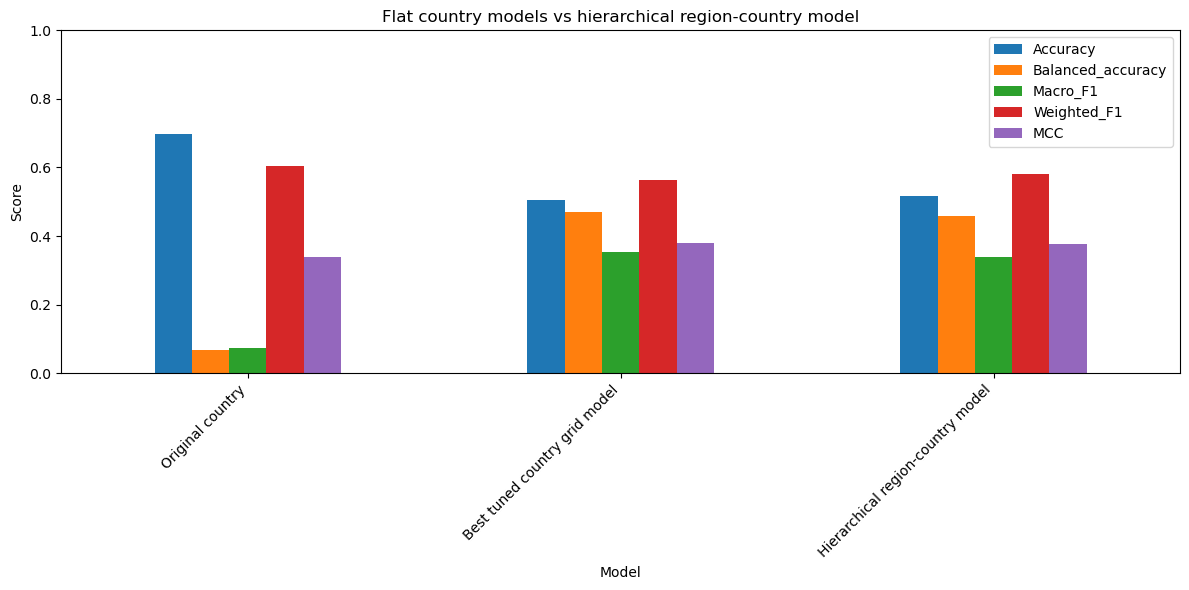

In [34]:
flat_vs_hierarchical = final_comparison_with_hierarchical[
    final_comparison_with_hierarchical["Model"].isin([
        "Original country",
        "Best tuned country grid model",
        "Hierarchical region-country model"
    ])
].copy()

display(flat_vs_hierarchical)

flat_vs_hierarchical.to_csv(
    "outputs/tables/flat_vs_hierarchical_country_comparison.csv",
    index=False
)

metrics_to_plot = [
    "Accuracy",
    "Balanced_accuracy",
    "Macro_F1",
    "Weighted_F1",
    "MCC"
]

plot_df = flat_vs_hierarchical.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(12, 6))

plt.ylabel("Score")
plt.title("Flat country models vs hierarchical region-country model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    "outputs/figures/flat_vs_hierarchical_country_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 34. Create final comparison table for baseline and tuned models

In [35]:
final_comparison = final_comparison_with_hierarchical.copy()

display(final_comparison)

final_comparison.to_csv(
    "outputs/tables/final_model_comparison_with_hierarchical.csv",
    index=False
)

,Model,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_F1,MCC
0,Original country,0.696386,0.066585,0.099883,0.066585,0.073899,0.604848,0.338827
1,Original region,0.713253,0.266474,0.434615,0.266474,0.303694,0.651259,0.392447
2,Best tuned country grid model,0.504202,0.471517,0.372550,0.471517,0.352600,0.563560,0.378915
3,Best tuned region grid model,0.549261,0.599096,0.466716,0.599096,0.469282,0.576004,0.429150
4,Hierarchical region-country model,0.518207,0.458553,0.407871,0.458553,0.337565,0.581088,0.377260


## 35. Figure - Multi-panel comparison of final models

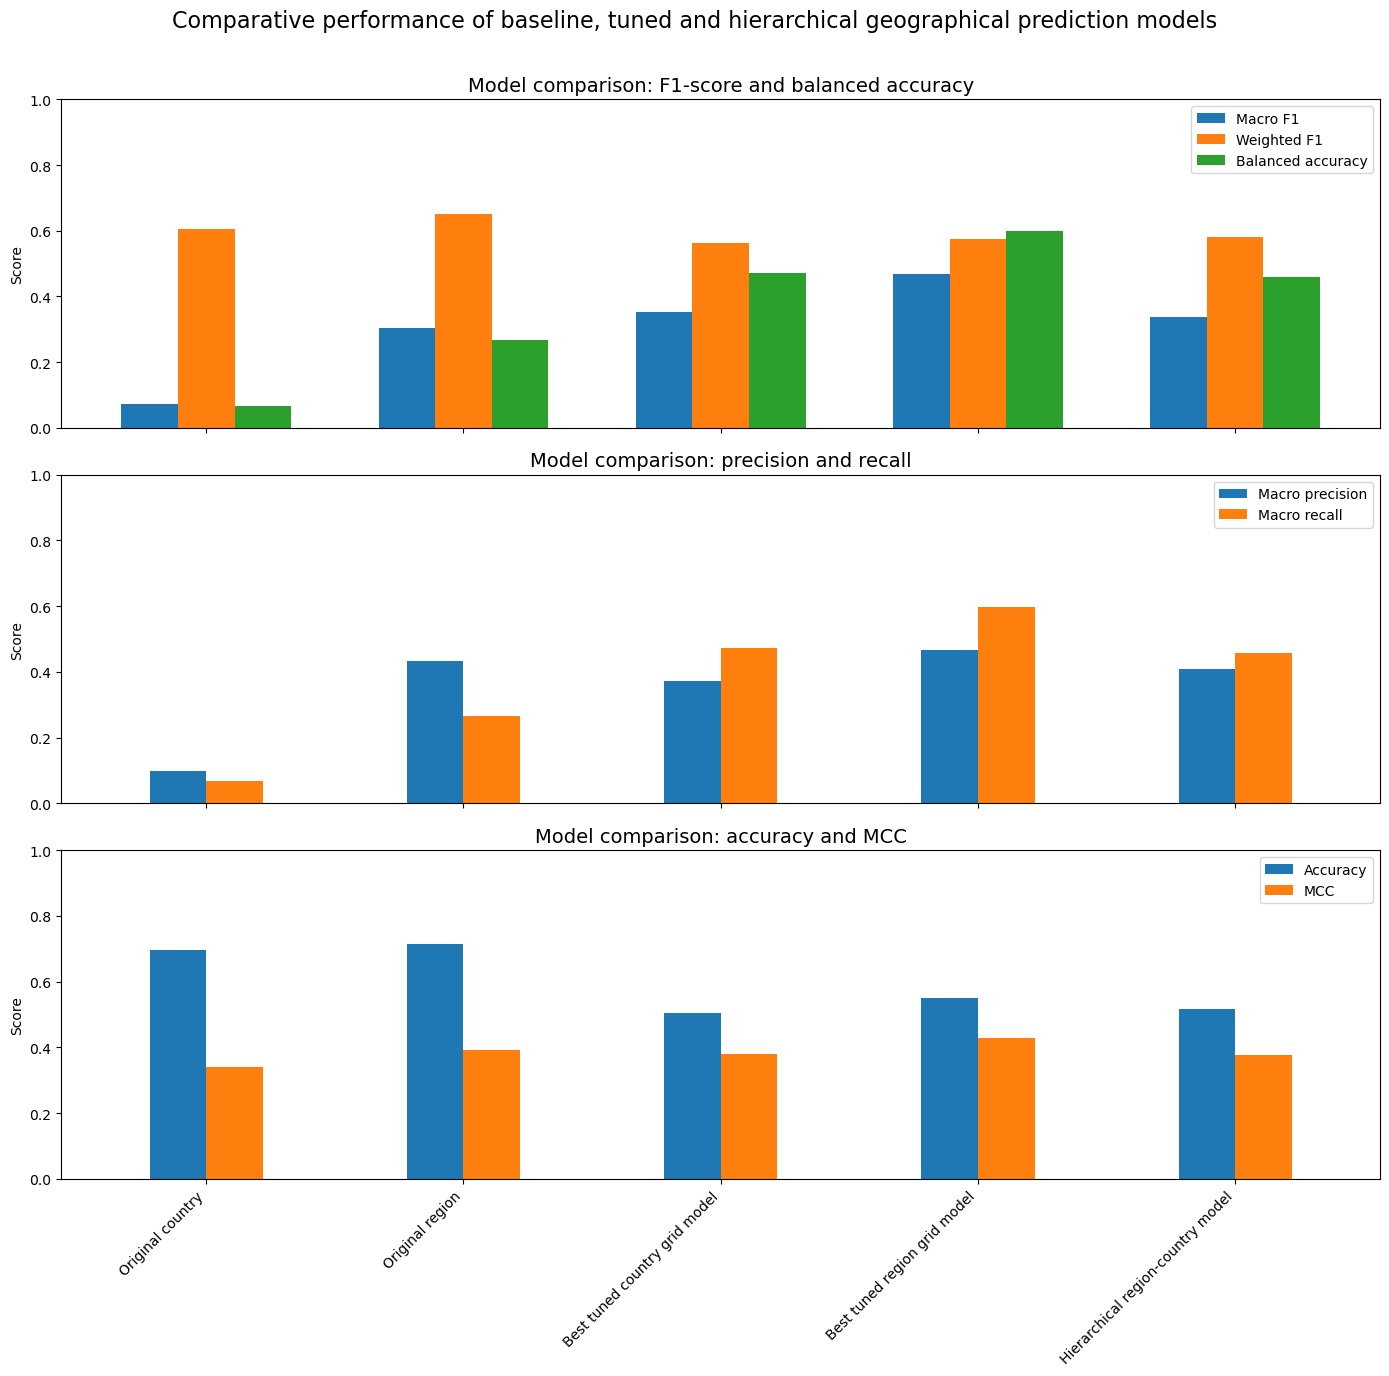

In [36]:
plot_df = final_comparison.copy()

model_order = [
    "Original country",
    "Original region",
    "Best tuned country grid model",
    "Best tuned region grid model",
    "Hierarchical region-country model"
]

plot_df["Model"] = pd.Categorical(
    plot_df["Model"],
    categories=model_order,
    ordered=True
)

plot_df = plot_df.sort_values("Model")

# Drop any accidental rows with missing model names
plot_df = plot_df.dropna(subset=["Model"])

x = np.arange(len(plot_df))
width = 0.22

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# Panel 1: F1 and balanced accuracy
axes[0].bar(x - width, plot_df["Macro_F1"], width, label="Macro F1")
axes[0].bar(x, plot_df["Weighted_F1"], width, label="Weighted F1")
axes[0].bar(x + width, plot_df["Balanced_accuracy"], width, label="Balanced accuracy")
axes[0].set_title("Model comparison: F1-score and balanced accuracy", fontsize=14)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend()

# Panel 2: Precision and recall
axes[1].bar(x - width/2, plot_df["Macro_precision"], width, label="Macro precision")
axes[1].bar(x + width/2, plot_df["Macro_recall"], width, label="Macro recall")
axes[1].set_title("Model comparison: precision and recall", fontsize=14)
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()

# Panel 3: Accuracy and MCC
axes[2].bar(x - width/2, plot_df["Accuracy"], width, label="Accuracy")
axes[2].bar(x + width/2, plot_df["MCC"], width, label="MCC")
axes[2].set_title("Model comparison: accuracy and MCC", fontsize=14)
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1)
axes[2].legend()

axes[2].set_xticks(x)
axes[2].set_xticklabels(plot_df["Model"], rotation=45, ha="right")

plt.suptitle(
    "Comparative performance of baseline, tuned and hierarchical geographical prediction models",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "outputs/figures/final_model_comparison_multipanel_with_hierarchical.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 36. Check true and predicted label distributions

In [37]:
print("Original country true labels:")
print(y_test_country.value_counts())

print("\nOriginal country predicted labels:")
print(pd.Series(country_pred).value_counts())

print("\nOriginal region true labels:")
print(y_test_region.value_counts())

print("\nOriginal region predicted labels:")
print(pd.Series(region_pred).value_counts())

print("\nBest grid country true labels:")
print(y_test_country_grid.value_counts())

print("\nBest grid country predicted labels:")
print(pd.Series(best_predictions).value_counts())

print("\nTuned region true labels:")
print(y_test_region_grid.value_counts())

print("\nTuned region predicted labels:")
print(pd.Series(tuned_region_pred).value_counts())

print("\nBest grid region true labels:")
print(y_test_region_grid.value_counts())

print("\nBest grid region predicted labels:")
print(pd.Series(best_region_predictions).value_counts())

Original country true labels:
Country
UK             267
Turkey          37
Spain           11
Egypt           11
Cyprus           9
Portugal         9
Greece           5
Tunisia          5
Poland           4
Netherlands      3
UAE              3
Indonesia        3
Malta            3
Israel           3
Morocco          3
Antigua          3
France           3
Australia        2
Mexico           2
India            2
Bulgaria         2
Italy            2
Croatia          2
China            2
Belgium          2
Denmark          2
Switzerland      1
Ireland          1
Hungary          1
Slovakia         1
Albania          1
Germany          1
Tanzania         1
Kenya            1
Nigeria          1
Pakistan         1
USA              1
Azerbaijan       1
Bangladesh       1
Thailand         1
Iran             1
Name: count, dtype: int64

Original country predicted labels:
UK           374
Turkey        30
Cyprus         3
Egypt          3
Indonesia      2
Kenya          1
Tanzania       1
Mo

## 37. Check all saved output files

In [38]:
print("Saved figures:")
print(os.listdir("outputs/figures"))

print("\nSaved tables:")
print(os.listdir("outputs/tables"))

print("\nSaved models:")
print(os.listdir("outputs/models"))

Saved figures:
['flat_vs_hierarchical_country_comparison.png', 'figure6_best_tuned_region_confusion_matrix.png', 'figure4_original_region_confusion_matrix.png', 'figure7_hierarchical_region_country_confusion_matrix.png', 'figure2_region_class_distribution.png', 'best_grid_country_top20_kmers_fixed.png', 'tuned_region_confusion_matrix.png', 'feature_size_performance_trend_region.png', 'best_grid_region_top20_kmers_fixed.png', 'hierarchical_region_country_confusion_matrix.png', 'figure1_country_class_distribution_cleaned.png', 'best_grid_country_confusion_matrix.png', 'best_grid_region_top20_kmers.png', 'final_model_comparison_multipanel.png', 'best_tuned_country_precision_heatmap.png', 'feature_size_performance_trend.png', 'final_model_comparison_multipanel_with_hierarchical.png', 'best_tuned_region_precision_heatmap.png', 'figure8_final_model_comparison_multipanel.png', 'figure3_original_country_confusion_matrix.png', 'figure5_best_tuned_country_confusion_matrix.png', 'precision_summar